In [ ]:
# 필요한 라이브러리 불러오기

import os
import re
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 폴더 확인

DATA_DIR = "../dataset"
print("dataset 폴더 파일 목록\n")

for f in sorted(os.listdir(DATA_DIR)):
    print(f)

dataset 폴더 파일 목록

.ipynb_checkpoints
01._격자_(4개_시·구).geojson
02._격자_(하남교산).geojson
03._성연령별_거주인구(격자).csv
04._성연령별_유동인구.csv
05._시간대별_직장인구.csv
06._시간대별_방문인구.csv
07._주중주말_서비스인구.csv
08.상세도로망_네트워크.geojson
09._평균속도.csv
10._추정교통량.csv
11._혼잡빈도강도.csv
12._혼잡시간강도.csv
13._교통사고이력.geojson
14._어린이보호구역.csv
15._학교현황.csv
16._유치원현황.csv
17._어린이집현황.csv
18._횡단보도_위치정보.csv
19._버스정류장_위치정보.csv
20._CCTV_현황.csv
21._과속방지턱_현황.csv
22._토지이용계획도_(4개_신도시).geojson
23._토지이용계획도_(하남교산).geojson
24._(참고자료)하남교산_공공주택지구_지구계획_변경(4차)_승인_고시문.pdf
25._교통데이터_코드표.csv
데이터셋 불러오기.ipynb


In [ ]:
# 1,2 번 데이터셋 전처리
# 1. 데이터 로드하기
grid4_fp = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
grid_gyosan_fp = os.path.join(DATA_DIR, "02._격자_(하남교산).geojson")

grid4 = gpd.read_file(grid4_fp)
grid_gyosan = gpd.read_file(grid_gyosan_fp)

print("데이터 로드 완료")

# 기본 정보들 확인하기
def check_grid(name, gdf):
    print('\n')
    print(name)
    print("=====================================")

    print("shape:", gdf.shape)

    print("\ncolumns:")
    print(gdf.columns.tolist())

    print("\nCRS:")
    print(gdf.crs)

    print("\ngeometry type:")
    print(gdf.geom_type.value_counts())

    print("\nhead:")
    display(gdf.head())

check_grid("4개 도시 격자", grid4)
check_grid("하남교산 격자", grid_gyosan)

데이터 로드 완료


4개 도시 격자
shape: (99323, 4)

columns:
['std_yr', 'gbn', 'gid', 'geometry']

CRS:
EPSG:4326

geometry type:
Polygon    99323
Name: count, dtype: int64

head:


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,2024,경기도 성남시,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,2024,경기도 성남시,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,2024,경기도 성남시,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."




하남교산 격자
shape: (770, 3)

columns:
['gbn', 'gid', 'geometry']

CRS:
EPSG:4326

geometry type:
Polygon    770
Name: count, dtype: int64

head:


,gbn,gid,geometry
0,경기도 하남시,다사720443,"POLYGON ((127.18323 37.49754, 127.18323 37.498..."
1,경기도 하남시,다사720444,"POLYGON ((127.18323 37.49844, 127.18323 37.499..."
2,경기도 하남시,다사721443,"POLYGON ((127.18436 37.49754, 127.18436 37.498..."
3,경기도 하남시,다사721444,"POLYGON ((127.18436 37.49844, 127.18436 37.499..."
4,경기도 하남시,다사721445,"POLYGON ((127.18436 37.49934, 127.18435 37.500..."


In [ ]:
# gid 키 확인
print("\n4개 도시 gid 확인")
print(grid4["gid"].head())
print("unique gid:", grid4["gid"].nunique())

print("\n하남교산 gid 확인")
print(grid_gyosan["gid"].head())
print("unique gid:", grid_gyosan["gid"].nunique())


4개 도시 gid 확인
0    다사581304
1    다사581305
2    다사581306
3    다사582304
4    다사582305
Name: gid, dtype: object
unique gid: 99146

하남교산 gid 확인
0    다사720443
1    다사720444
2    다사721443
3    다사721444
4    다사721445
Name: gid, dtype: object
unique gid: 770


## 01._격자_ (4개_시·구).geojson

데이터 설명:

    - **성남시, 화성시, 하남시, 부천시** 등 4개 도시를 한 격자 기반 공간 데이터
    - 모든 분석의 공간 단위로 사용
    - 격자 : 일정한 크기의 공간 단위로 도시를 분할하여 **교통,인구,시설,사고** 데이터를 동일한 기준으로 집계하기 위해 사용
    
데이터 특징:

    - 총 99,323개의 격자로 구성
    - 각 격자는 **Polygon 형태의 공간 객체**
    - 좌표계 : **EPSG:4326(WGS84)**


## 02._격자_ (하남교산).geojson

데이터 설명:

    - 신도시 개발 예정 지역인 **하남교산 지역**을 동일한 격자 체계로 분할한 공간 데이터
    - 추후에 있을 하남교산에 적용하여 **잠재 사고 위험을 예측**하기 위해 사용한 데이터
   
데이터 특징:

    - 총 770개의 격자
    - 좌표계 마찬가지로 **EPSG:4326**

In [ ]:
# 3번 데이터셋 불러오기 (거주인구)
pop_fp = os.path.join(DATA_DIR, "03._성연령별_거주인구(격자).csv")
pop = pd.read_csv(pop_fp)

print("데이터 로드 완료")

# 기본정보 확인하기
print('\n기본 정보')
print("==============================")

print("shape:", pop.shape)

print("\ncolumns:")
print(pop.columns.tolist())

print("\nhead:")
display(pop.head())

데이터 로드 완료

기본 정보
shape: (99323, 21)

columns:
['gbn', 'gid', 'year', 'm_20g_pop', 'w_20g_pop', 'm_30g_pop', 'w_30g_pop', 'm_40g_pop', 'w_40g_pop', 'm_50g_pop', 'w_50g_pop', 'm_60g_pop', 'w_60g_pop', 'm_70g_pop', 'w_70g_pop', 'm_80g_pop', 'w_80g_pop', 'm_90g_pop', 'w_90g_pop', 'm_100g_pop', 'w_100g_pop']

head:


,gbn,gid,year,m_20g_pop,w_20g_pop,m_30g_pop,w_30g_pop,m_40g_pop,w_40g_pop,m_50g_pop,...,m_60g_pop,w_60g_pop,m_70g_pop,w_70g_pop,m_80g_pop,w_80g_pop,m_90g_pop,w_90g_pop,m_100g_pop,w_100g_pop
0,경기도 성남시,다사581304,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,경기도 성남시,다사581305,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,경기도 성남시,다사581306,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,경기도 성남시,다사582304,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,경기도 성남시,다사582305,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# head에 결측치가 많아서 결측치 확인하기 코드
print("결측치 비율")
print("==============================")

missing = pop.isnull().mean().sort_values(ascending=False)

print(missing.head(20))

결측치 비율
m_100g_pop    0.999003
w_100g_pop    0.995882
m_90g_pop     0.969604
w_90g_pop     0.939712
m_80g_pop     0.903769
w_80g_pop     0.889492
w_20g_pop     0.889401
w_30g_pop     0.883270
w_40g_pop     0.882656
m_20g_pop     0.877380
m_30g_pop     0.866174
w_70g_pop     0.864593
m_40g_pop     0.861684
w_50g_pop     0.860214
m_70g_pop     0.857878
w_60g_pop     0.837520
m_50g_pop     0.837178
m_60g_pop     0.816276
gid           0.000000
year          0.000000
dtype: float64


In [ ]:
print("기초 통계")
print("==============================")

display(pop.describe())

기초 통계


,year,m_20g_pop,w_20g_pop,m_30g_pop,w_30g_pop,m_40g_pop,w_40g_pop,m_50g_pop,w_50g_pop,m_60g_pop,w_60g_pop,m_70g_pop,w_70g_pop,m_80g_pop,w_80g_pop,m_90g_pop,w_90g_pop,m_100g_pop,w_100g_pop
count,99323.0,12179.000000,10985.000000,13292.000000,11594.000000,13738.000000,11655.000000,16172.000000,13884.000000,18248.000000,16138.000000,14116.000000,13449.000000,9558.000000,10976.000000,3019.000000,5988.000000,99.0,409.0
mean,2024.0,12.286148,13.416568,16.523322,18.211057,17.380186,20.266323,13.318884,15.281547,8.852203,10.570517,5.484627,6.607108,2.058590,2.977132,0.071878,0.350701,0.0,0.0
std,0.0,15.925409,18.019164,26.884695,28.456156,23.824852,25.591579,19.466740,20.715392,14.879167,16.751826,9.520043,10.943170,4.496324,6.033598,1.086608,1.988842,0.0,0.0
min,2024.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,2024.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
50%,2024.0,8.000000,10.000000,9.000000,11.000000,9.000000,13.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
75%,2024.0,20.000000,20.000000,24.000000,26.000000,28.000000,31.000000,22.000000,26.000000,14.000000,17.000000,9.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.0,0.0
max,2024.0,337.000000,535.000000,1225.000000,1405.000000,688.000000,689.000000,367.000000,459.000000,277.000000,269.000000,126.000000,129.000000,78.000000,92.000000,42.000000,66.000000,0.0,0.0


# 03._성연령별_거주인구(격자).csv

데이터 구조:

    - 기준 연도, 격자 ID, 20대~100대 이상까지 남성/여성인구가 잘 저장되어 있음.
    
데이터 특성:

    - 결측치 비율이 매우 높음. (100세인구 이상으로는 99.9%의 결측 비율이 존재)
    - 20~40대 인구는 비교적 분포가 존재

분석을 위한 고려사항:

    - 결측값 처리 : 대부분의 결측치는 **실제 인구가 존재하지 않는 경우로 해석될 가능성** 존재  
    - 사고 예측에 거주인구 데이터는 휴리스틱적 관점으로 필요하다고 생각하여 결측치 있는 데이터를 직접 모델에 사용하기보다, 전처리를 수행한 후 단위 인구 변수로 활용하기로 결정

In [ ]:
# 인구 컬럼 찾기 (_pop으로 끝나는 컬럼), 결측값을 잠시 0으로 처리하여 전체 인구 합계 컬럼을 생성
# 전체 인구의 총합을 확인해주는 코드


pop_cols = [c for c in pop.columns if c.endswith("_pop")]
pop[pop_cols] = pop[pop_cols].fillna(0)
pop["sum"] = pop[pop_cols].sum(axis=1)

total_population = pop["sum"].sum()

print("\n총 인구 합계:", total_population)
display(pop[["gid", "sum"]].head())


총 인구 합계: 2183388.0


,gid,sum
0,다사581304,0.0
1,다사581305,0.0
2,다사581306,0.0
3,다사582304,0.0
4,다사582305,0.0


### 거주인구 데이터 확인

격자별 연령, 성별 인구 데이터를 합산하여 전체 인구 'sum'을 계산

    - 총 인구는 2,183,388명으로 나타남
    - 일반적인 신도시 인구 규모와 비교할 때 해당 값은 실제 거주인구 수를 충분히 반영하지 못한다고 판단
    - 아래는 QGIS에서 격자 단위로 시각화한 결과, 많은 격자에서 sum = 0으로 나타남

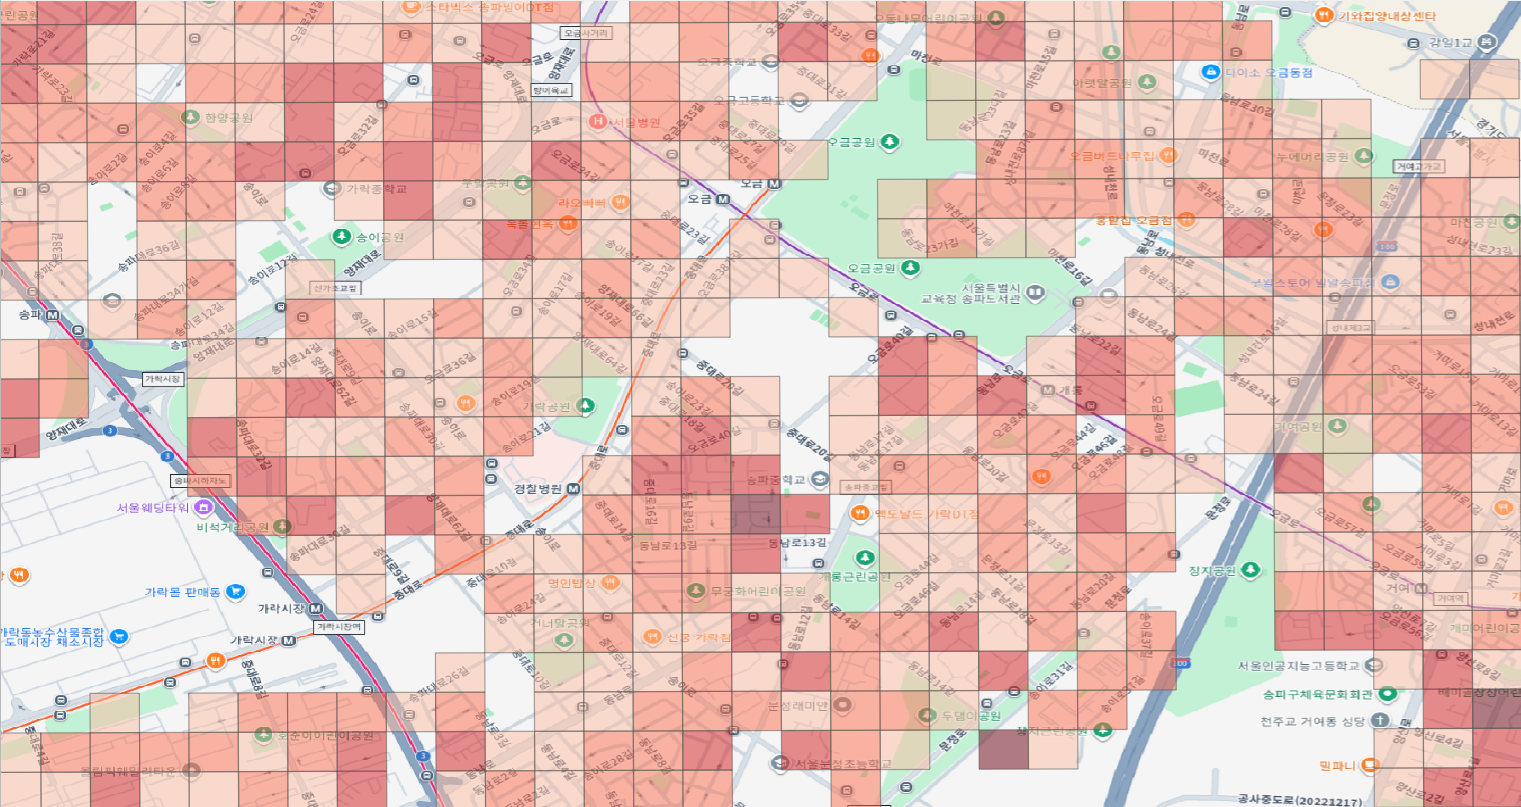

In [ ]:
# QGIS 격자 단위 시각화 한 사진
from IPython.display import Image,display

img_fp = "../Images/거주인구 데이터(격자).png"
display(Image(filename=img_fp))

### 거주인구 데이터 시각화 해석 및 활용 방안

거주인구 데이터셋에서 격자 단위 총 인구를 QGIS에서 시각화한 결과이다.
시각화 한 결과를 확인한 바, 'sum = 0' 으로 나타나는 격자는 실제 지도 상에서 *공원, 녹지, 도로, 하천* 등과 같이 사람이 거주하지 않는 지역에 있는 경우를 확인할 수 있었다.

결과 해석:

    - 인구 데이터의 총합이 정확하지는 않아 보이더라도 실제 공간적 인구 분포를 반영하고 있다고 생각
    - 다만, 결측치 때문에 데이터셋을 바로 분석에 넣기에는 어렵다고 판단
    - 실제 **2024년 인구 수**를 기반으로 인구 분포를 반영한 데이터셋을 다시 생성
(01-1_거주인구_데이터셋_전처리.ipynb)파일을 통해 생성

In [ ]:
# 4번 데이터셋 확인하기

fp = os.path.join(DATA_DIR, "04._성연령별_유동인구.csv")

df_04 = pd.read_csv(fp)

print("shape:", df_04.shape)
display(df_04.head())

shape: (3416198, 16)


,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,0.01,0.01,0.03,0.04,127.027716,37.372890
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,127.028241,37.379202
2,경기도 성남시,202401,0.0,0.00,0.01,0.02,0.03,0.05,0.00,0.00,0.01,0.01,0.01,0.03,127.028272,37.374244
3,경기도 성남시,202401,0.0,0.01,0.02,0.03,0.04,0.07,0.01,0.01,0.02,0.01,0.03,0.04,127.028275,37.373793
4,경기도 성남시,202401,0.0,0.01,0.02,0.04,0.06,0.11,0.01,0.01,0.02,0.01,0.04,0.06,127.028278,37.373343


In [ ]:
df_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3416198 entries, 0 to 3416197
Data columns (total 16 columns):
 #   Column     Dtype  
---  ------     -----  
 0   gbn        object 
 1   STD_YM     int64  
 2   m_10g_pop  float64
 3   m_20g_pop  float64
 4   m_30g_pop  float64
 5   m_40g_pop  float64
 6   m_50g_pop  float64
 7   m_60g_pop  float64
 8   w_10g_pop  float64
 9   w_20g_pop  float64
 10  w_30g_pop  float64
 11  w_40g_pop  float64
 12  w_50g_pop  float64
 13  w_60g_pop  float64
 14  lon        float64
 15  lat        float64
dtypes: float64(14), int64(1), object(1)
memory usage: 417.0+ MB


In [ ]:
# 유동인구 4번 데이터 전처리

# 음수 인구 값 존재 여부 확인 -> 음수 값이 존재하면 데이터 오류일 가능성이 높기 때문
# 데이터의 시간 범위 확인 (최소,최대)를 통해 데이터가 어떤 기간을 포함하는지 파악
# 결측치 확인 -> 컬럼별 전처리 여부 파악

(df_04.filter(like="_pop") < 0).sum().sum()
df_04["STD_YM"].min(), df_04["STD_YM"].max()
df_04.isna().sum()

gbn          0
STD_YM       0
m_10g_pop    0
m_20g_pop    0
m_30g_pop    0
m_40g_pop    0
m_50g_pop    0
m_60g_pop    0
w_10g_pop    0
w_20g_pop    0
w_30g_pop    0
w_40g_pop    0
w_50g_pop    0
w_60g_pop    0
lon          0
lat          0
dtype: int64

# 04._성연령별_유동인구.csv

데이터 개요:

    - **격자 또는 좌표 단위**에서 시간대별 성별, 연령별 유동인구 분포를 나타내는 데이터
    - 특정위치 : 실제로 머무르거나 이동하는 사람 수를 반영하는 데이터
        : 거주인구와 달리 생활권 내 활동 인구 규모를 파악할 수 있음.
본 연구 : 실제 사고는 사람이 많이 이동하고 머무르는 지역에서 더 자주 발생할 가능성이 높기 때문에, 유동인구 데이터는 **교통 위험의 노출도(exposure)** 를 실명하는 중요한 변수로 활용될 수 있음.

데이터 활용:

**유동인구를 공간 단위로 통합**

    - 원본 데이터는 좌표 기반 점 데이터, 이를 그대로 분석에 사용하기 어려움
    - 4개 도시 격자 데이터와 공간 결합을 수행해서 각 유동인구 점에 gid를 부여해서 **격자 단위 데이터셋으로 변환하고자 함.**
    - 격자 단위 노출도 변수 생성 : 총 유동인구, 연령대별 유동인구, 성별 유동인구
    - 교통사고 위험도 모델의 설명 변수로 활용

**전처리 필요성**
04번 데이터셋은 위경도 기반 점 데이터 : 격자 단위 분석에 직접 활용하기 어려움
lon,lat을 활용해 GeoDataFrame으로 변환해서 4개 도시 격자와 Spatial Join을 수행 후 추후에 있을 격자 단위로 집계 가능한 형태로 재구성하는 작업 수행

In [ ]:
DATA_DIR = "../dataset"
OUT_DIR = "../outputs/processed"
os.makedirs(OUT_DIR, exist_ok=True)

grid_fp = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
flow_fp = os.path.join(DATA_DIR, "04._성연령별_유동인구.csv")

grid = gpd.read_file(grid_fp)
df_04 = pd.read_csv(flow_fp)

print("grid shape:", grid.shape)
print("flow shape:", df_04.shape)
print("grid CRS:", grid.crs)

# 1. 점 데이터 -> GeoDataFrame 변환
# 유동인구 데이터의 lon, lat 컬럼을 이용해 Point geometry 생성
gdf_04 = gpd.GeoDataFrame(
    df_04,
    geometry=gpd.points_from_xy(df_04["lon"], df_04["lat"]),
    crs="EPSG:4326"
)


# 2. 1차 Spatial Join (within)
# 점이 격자 내부에 완전히 포함되는 경우 gid를 부여
gdf_joined = gpd.sjoin(
    gdf_04,
    grid[["gid", "geometry"]],
    how="left",
    predicate="within"
)

print("\n[within 기준]")
print("gid 결측 개수:", gdf_joined["gid"].isna().sum())

# 3. 결측이 발생한 지역 확인
print("\n[gid 결측 데이터의 gbn 분포]")
print(gdf_joined[gdf_joined["gid"].isna()]["gbn"].value_counts().head(20))


# 3. 2차 Spatial Join (intersects)
# within으로 누락된 경계선 데이터까지 포함할 수 있도록 intersects도 확인
gdf_joined2 = gpd.sjoin(
    gdf_04,
    grid[["gid", "geometry"]],
    how="left",
    predicate="intersects"
)

print("\n[intersects 기준]")
print("gid 결측 개수:", gdf_joined2["gid"].isna().sum())

# 4. 결측 데이터 좌표 범위 확인
# =========================
na = gdf_joined2[gdf_joined2["gid"].isna()].copy()

if len(na) > 0:
    print("\n[gid 결측 데이터 좌표 범위]")
    display(na[["lon", "lat"]].describe())
else:
    print("\n모든 데이터에 gid가 정상적으로 부여됨")

# 5. 특정 도시 예시 확인 (경기도 화성시)
# =========================
ok = gdf_joined2[
    (gdf_joined2["gbn"] == "경기도 화성시") & (~gdf_joined2["gid"].isna())
]
na_hs = gdf_joined2[
    (gdf_joined2["gbn"] == "경기도 화성시") & (gdf_joined2["gid"].isna())
]

print("\n[화성시 기준 매핑 결과]")
print("정상 매핑:", ok.shape)
print("결측 매핑:", na_hs.shape)

if len(ok) > 0:
    print("\n[정상 매핑 좌표 범위]")
    display(ok[["lon", "lat"]].describe())

if len(na_hs) > 0:
    print("\n[결측 매핑 좌표 범위]")
    display(na_hs[["lon", "lat"]].describe())


# 6. 최종 결과 저장
# =========================
# 일반적으로 intersects 결과를 최종본으로 사용하는 것이 경계 누락을 줄이는 데 유리함
out_fp = os.path.join(OUT_DIR, "04_flow_population_with_gid.csv")
gdf_joined2.drop(columns="geometry").to_csv(out_fp, index=False, encoding="utf-8-sig")

print("\n저장 완료:", out_fp)

grid shape: (99323, 4)
flow shape: (3416198, 16)
grid CRS: EPSG:4326

[within 기준]
gid 결측 개수: 20015

[gid 결측 데이터의 gbn 분포]
gbn
경기도 화성시    20015
Name: count, dtype: int64

[intersects 기준]
gid 결측 개수: 20015

[gid 결측 데이터 좌표 범위]


,lon,lat
count,20015.000000,20015.000000
mean,126.685479,37.229010
std,0.081347,0.036312
min,126.550038,37.028112
25%,126.656936,37.208612
50%,126.662533,37.236988
75%,126.671920,37.250926
max,127.042043,37.294308



[화성시 기준 매핑 결과]
정상 매핑: (2433658, 19)
결측 매핑: (20015, 19)

[정상 매핑 좌표 범위]


,lon,lat
count,2.433658e+06,2.433658e+06
mean,1.268849e+02,3.716542e+01
std,1.160301e-01,5.966568e-02
min,1.265495e+02,3.701344e+01
25%,1.268045e+02,3.712193e+01
50%,1.268759e+02,3.717397e+01
75%,1.269623e+02,3.721041e+01
max,1.271612e+02,3.729387e+01



[결측 매핑 좌표 범위]


,lon,lat
count,20015.000000,20015.000000
mean,126.685479,37.229010
std,0.081347,0.036312
min,126.550038,37.028112
25%,126.656936,37.208612
50%,126.662533,37.236988
75%,126.671920,37.250926
max,127.042043,37.294308



저장 완료: ../outputs/processed/04_flow_population_with_gid.csv


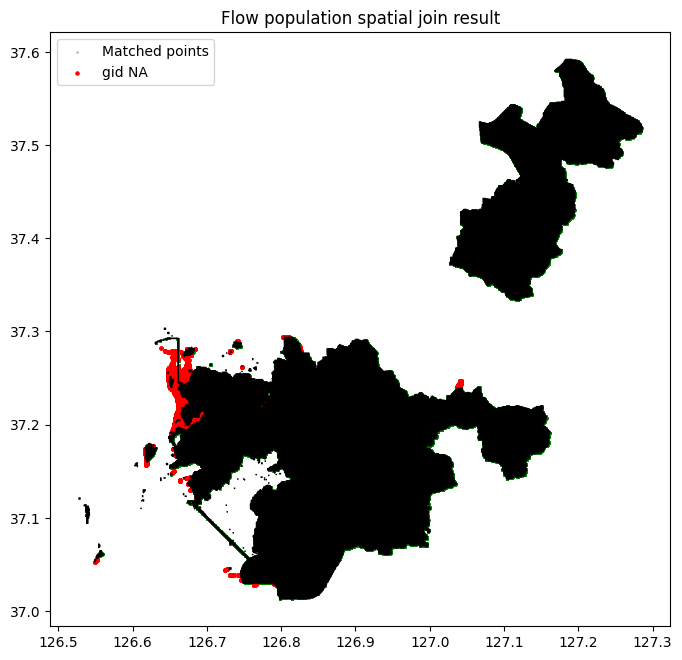

In [ ]:
# 유동인구 점 데이터가 격자에 정상적으로 매핑되었는지 확인
fig, ax = plt.subplots(figsize=(8,8))
grid.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color="black"
)

gdf_joined2[~gdf_joined2["gid"].isna()].plot(
    ax=ax,
    markersize=1,
    color="green",
    alpha=0.3,
    label="Matched points"
)

gdf_joined2[gdf_joined2["gid"].isna()].plot(
    ax=ax,
    markersize=5,
    color="red",
    label="gid NA"
)

plt.title("Flow population spatial join result")
plt.legend()


plt.show()

### 유동인구 데이터의 격자 매핑 결과

유동인구 점 데이터를 4개 도시 격자와 Spatial Join한 후, 매핑 결과 시각화
점 : 격자에 정상적으로 매핑된 데이터
빨간색 점 : 매핑되지 않은 점

    - 대부분의 유동인구 데이터가 격자에 정상적으로 매핑된 것을 확인하였지만,
    이후 분석에서는 격자에 정상적으로 매핑된 데이터가 존재하는 데이터를 활용하여
    격자 단위 유동인구 집계

In [ ]:
# gid가 정상적으로 매핑된 데이터만 유지
gdf_final = gdf_joined2[~gdf_joined2["gid"].isna()].copy()

print("원본 행 수 :", len(gdf_joined2))
print("유지 행 수 :", len(gdf_final))
print("제거 행 수 :", gdf_joined2["gid"].isna().sum())

display(gdf_final.head())

원본 행 수 : 3424552
유지 행 수 : 3404537
제거 행 수 : 20015


,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat,geometry,index_right,gid
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,0.01,0.01,0.03,0.04,127.027716,37.372890,POINT (127.02772 37.37289),1.0,다사581305
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,127.028241,37.379202,POINT (127.02824 37.37920),11.0,다사582312
2,경기도 성남시,202401,0.0,0.00,0.01,0.02,0.03,0.05,0.00,0.00,0.01,0.01,0.01,0.03,127.028272,37.374244,POINT (127.02827 37.37424),5.0,다사582306
3,경기도 성남시,202401,0.0,0.01,0.02,0.03,0.04,0.07,0.01,0.01,0.02,0.01,0.03,0.04,127.028275,37.373793,POINT (127.02828 37.37379),5.0,다사582306
4,경기도 성남시,202401,0.0,0.01,0.02,0.04,0.06,0.11,0.01,0.01,0.02,0.01,0.04,0.06,127.028278,37.373343,POINT (127.02828 37.37334),4.0,다사582305


In [ ]:
# 분석용 테이블로 변환
# geometry, index_right는 이후 집계 단계에서 불필요하므로 제거
drop_cols = [c for c in ["geometry", "index_right"] if c in gdf_final.columns]
df_04_gid = gdf_final.drop(columns=drop_cols)

display(df_04_gid.head())

,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat,gid
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,0.01,0.01,0.03,0.04,127.027716,37.372890,다사581305
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,127.028241,37.379202,다사582312
2,경기도 성남시,202401,0.0,0.00,0.01,0.02,0.03,0.05,0.00,0.00,0.01,0.01,0.01,0.03,127.028272,37.374244,다사582306
3,경기도 성남시,202401,0.0,0.01,0.02,0.03,0.04,0.07,0.01,0.01,0.02,0.01,0.03,0.04,127.028275,37.373793,다사582306
4,경기도 성남시,202401,0.0,0.01,0.02,0.04,0.06,0.11,0.01,0.01,0.02,0.01,0.04,0.06,127.028278,37.373343,다사582305


In [ ]:
# 연령대를 3개 그룹으로 단순화
# child_pop   : 10대 이하
# general_pop : 20~50대
# elderly_pop : 60대 이상

df_04_gid["child_pop"] = df_04_gid["m_10g_pop"] + df_04_gid["w_10g_pop"]

df_04_gid["elderly_pop"] = df_04_gid["m_60g_pop"] + df_04_gid["w_60g_pop"]

df_04_gid["general_pop"] = df_04_gid[
    [
        "m_20g_pop", "m_30g_pop", "m_40g_pop", "m_50g_pop",
        "w_20g_pop", "w_30g_pop", "w_40g_pop", "w_50g_pop"
    ]
].sum(axis=1)

df_04_gid["total_pop"] = (
    df_04_gid["child_pop"] +
    df_04_gid["elderly_pop"] +
    df_04_gid["general_pop"]
)

display(df_04_gid.head())

,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,...,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat,gid,child_pop,elderly_pop,general_pop,total_pop
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,...,0.01,0.03,0.04,127.027716,37.372890,다사581305,0.01,0.12,0.15,0.28
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,...,0.00,0.00,0.01,127.028241,37.379202,다사582312,0.00,0.02,0.00,0.02
2,경기도 성남시,202401,0.0,0.00,0.01,0.02,0.03,0.05,0.00,0.00,...,0.01,0.01,0.03,127.028272,37.374244,다사582306,0.00,0.08,0.09,0.17
3,경기도 성남시,202401,0.0,0.01,0.02,0.03,0.04,0.07,0.01,0.01,...,0.01,0.03,0.04,127.028275,37.373793,다사582306,0.01,0.11,0.17,0.29
4,경기도 성남시,202401,0.0,0.01,0.02,0.04,0.06,0.11,0.01,0.01,...,0.01,0.04,0.06,127.028278,37.373343,다사582305,0.01,0.17,0.21,0.39


In [ ]:
# 전체 중복 행 확인
# gid, STD_YM, lon, lat 기준 중복 확인
# 격자-시점별 데이터 개수 분포 확인

print("전체 중복 행 수:", df_04_gid.duplicated().sum())
dup_cnt = df_04_gid.duplicated(subset=["gid", "STD_YM", "lon", "lat"]).sum()
print("gid, STD_YM, lon, lat 기준 중복 수:", dup_cnt)
display(df_04_gid.groupby(["gid", "STD_YM"]).size().describe())

전체 중복 행 수: 8354
gid, STD_YM, lon, lat 기준 중복 수: 8354


count    1.034590e+06
mean     3.290711e+00
std      1.054213e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      1.200000e+01
dtype: float64

In [ ]:
# 인구 관련 컬럼 기초 통계 확인
display(df_04_gid.filter(like="_pop").describe())

,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,child_pop,elderly_pop,general_pop,total_pop
count,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06,3.404537e+06
mean,2.169783e+00,3.199685e+00,5.945311e+00,8.982323e+00,8.978622e+00,8.931579e+00,2.221734e+00,2.866757e+00,4.093073e+00,5.921798e+00,4.904737e+00,5.645911e+00,4.391517e+00,1.457749e+01,4.489231e+01,6.386131e+01
std,1.304570e+01,1.673633e+01,2.695330e+01,3.671966e+01,3.499435e+01,3.639759e+01,1.358666e+01,1.810109e+01,2.095286e+01,2.883132e+01,2.158489e+01,2.652758e+01,2.657754e+01,6.220405e+01,1.965785e+02,2.772358e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02
25%,1.000000e-02,3.000000e-02,6.000000e-02,1.200000e-01,1.600000e-01,1.700000e-01,1.000000e-02,1.000000e-02,2.000000e-02,4.000000e-02,5.000000e-02,7.000000e-02,2.000000e-02,2.400000e-01,5.300000e-01,8.100000e-01
50%,6.000000e-02,2.000000e-01,4.300000e-01,7.800000e-01,9.300000e-01,9.200000e-01,5.000000e-02,1.000000e-01,1.600000e-01,2.700000e-01,3.100000e-01,3.700000e-01,1.100000e-01,1.320000e+00,3.340000e+00,4.880000e+00
75%,6.200000e-01,1.310000e+00,2.670000e+00,4.520000e+00,4.900000e+00,4.720000e+00,5.900000e-01,8.700000e-01,1.400000e+00,2.180000e+00,2.160000e+00,2.390000e+00,1.210000e+00,7.210000e+00,2.076000e+01,2.982000e+01
max,3.618910e+03,2.316610e+03,2.739050e+03,2.894780e+03,3.306730e+03,3.118940e+03,3.505620e+03,2.787690e+03,1.734980e+03,4.792750e+03,1.893490e+03,2.239420e+03,7.124530e+03,4.760560e+03,1.507207e+04,2.470771e+04


In [ ]:
# 총 유동인구 대비 아동/고령 비율 생성
# total_pop = 0인 경우 division by zero 방지

df_04_gid["child_ratio"] = 0
df_04_gid["elderly_ratio"] = 0

mask = df_04_gid["total_pop"] > 0
df_04_gid.loc[mask, "child_ratio"] = df_04_gid.loc[mask, "child_pop"] / df_04_gid.loc[mask, "total_pop"]
df_04_gid.loc[mask, "elderly_ratio"] = df_04_gid.loc[mask, "elderly_pop"] / df_04_gid.loc[mask, "total_pop"]

display(df_04_gid.head())

,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,...,w_60g_pop,lon,lat,gid,child_pop,elderly_pop,general_pop,total_pop,child_ratio,elderly_ratio
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,...,0.04,127.027716,37.372890,다사581305,0.01,0.12,0.15,0.28,0.035714,0.428571
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,...,0.01,127.028241,37.379202,다사582312,0.00,0.02,0.00,0.02,0.000000,1.000000
2,경기도 성남시,202401,0.0,0.00,0.01,0.02,0.03,0.05,0.00,0.00,...,0.03,127.028272,37.374244,다사582306,0.00,0.08,0.09,0.17,0.000000,0.470588
3,경기도 성남시,202401,0.0,0.01,0.02,0.03,0.04,0.07,0.01,0.01,...,0.04,127.028275,37.373793,다사582306,0.01,0.11,0.17,0.29,0.034483,0.379310
4,경기도 성남시,202401,0.0,0.01,0.02,0.04,0.06,0.11,0.01,0.01,...,0.06,127.028278,37.373343,다사582305,0.01,0.17,0.21,0.39,0.025641,0.435897


In [ ]:
import os

OUT_DIR = "../outputs/processed"
os.makedirs(OUT_DIR, exist_ok=True)

out_fp = os.path.join(OUT_DIR, "04_flow_population_processed.csv")

df_04_gid.to_csv(
    out_fp,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", out_fp)
print("shape:", df_04_gid.shape)

저장 완료: ../outputs/processed/04_flow_population_processed.csv
shape: (3404537, 23)


### 4번 유동인구 데이터 전처리

격자와 Spatial Join을 통해 'gid'가 부여된 유동인구 데이터만 유지하였다.
이후 분석의 해석 가능성을 높이기 위해 연령대를 아래와 같이 3개 그룹으로 재구성하였다.

    - 'child_pop' : 10대 이하
    - 'general_pop' : 20~50대
    - 'elderly_pop' : 60대 이상
    
또한 각 지점의 총 유동인구를 계산하고, 총 유동인구 대비 아동 및 고령인구 비율('child_ratio', 'elderly_ratio')를 생성하였다.
격자 단위의 위험도 분석에서 **생활 인구 기반 노출도 변수**로 활용할 수 있는 형태로 전처리를 수행하였다.

In [ ]:
file_05 = os.path.join(DATA_DIR, "05._시간대별_직장인구.csv")

df_05 = pd.read_csv(
    file_05,
    encoding="utf-8",
    engine="python"
)

print("shape:", df_05.shape)
display(df_05.head())

shape: (3044614, 28)


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_16,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0050,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0050,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892


In [ ]:
# 결측치 확인, 및 기초 통계치 확인


print("컬럼별 결측치 개수")
print(df_05.isna().sum())
display(df_05.describe())

컬럼별 결측치 개수
gbn             0
STD_YM          0
TMST_00    324253
TMST_01    328941
TMST_02    332119
TMST_03    339661
TMST_04    335415
TMST_05    306927
TMST_06    263652
TMST_07    189004
TMST_08    162316
TMST_09    149829
TMST_10    146998
TMST_11    154723
TMST_12    156803
TMST_13    153249
TMST_14    152245
TMST_15    150927
TMST_16    171425
TMST_17    210722
TMST_18    262525
TMST_19    293998
TMST_20    313273
TMST_21    314007
TMST_22    313408
TMST_23    325797
lon             0
lat             0
dtype: int64


,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,TMST_08,...,TMST_16,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat
count,3.044614e+06,2.720361e+06,2.715673e+06,2.712495e+06,2.704953e+06,2.709199e+06,2.737687e+06,2.780962e+06,2.855610e+06,2.882298e+06,...,2.873189e+06,2.833892e+06,2.782089e+06,2.750616e+06,2.731341e+06,2.730607e+06,2.731206e+06,2.718817e+06,3.044614e+06,3.044614e+06
mean,2.024065e+05,1.132412e-02,1.032711e-02,9.926111e-03,9.751089e-03,1.011049e-02,1.237493e-02,1.857711e-02,3.378486e-02,5.362713e-02,...,6.520789e-02,5.461646e-02,4.047543e-02,3.207315e-02,2.537067e-02,2.065200e-02,1.691126e-02,1.313531e-02,1.269610e+02,3.725383e+01
std,3.444318e+00,4.131708e-02,3.770800e-02,3.586973e-02,3.515522e-02,3.603071e-02,4.301503e-02,6.650013e-02,1.316041e-01,2.275667e-01,...,3.074729e-01,2.587853e-01,1.870030e-01,1.427741e-01,1.085197e-01,8.462455e-02,6.603300e-02,4.977201e-02,1.580588e-01,1.470064e-01
min,2.024010e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.265193e+02,3.700317e+01
25%,2.024040e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.754386e-04,1.250000e-03,2.539682e-03,...,2.631579e-03,1.612903e-03,6.060606e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.268322e+02,3.715002e+01
50%,2.024070e+05,7.317073e-04,6.451613e-04,6.250000e-04,6.349206e-04,7.692308e-04,1.521739e-03,3.600000e-03,7.272726e-03,1.000000e-02,...,1.000000e-02,8.461539e-03,5.581396e-03,3.793103e-03,2.222222e-03,1.406250e-03,1.034483e-03,8.333333e-04,1.269526e+02,3.720558e+01
75%,2.024100e+05,6.037736e-03,5.468750e-03,5.396825e-03,5.312500e-03,5.714286e-03,7.812500e-03,1.210526e-02,2.035088e-02,2.906249e-02,...,3.063492e-02,2.488889e-02,1.843750e-02,1.466667e-02,1.100000e-02,9.062500e-03,7.714286e-03,6.562500e-03,1.271107e+02,3.738630e+01
max,2.024120e+05,4.454063e+00,5.323437e+00,5.659688e+00,5.901719e+00,5.836250e+00,5.587500e+00,5.525938e+00,1.097547e+01,1.440047e+01,...,1.680766e+01,1.286312e+01,9.318437e+00,6.625782e+00,4.281563e+00,3.374844e+00,3.018182e+00,3.662812e+00,1.272854e+02,3.759155e+01


In [ ]:
# 직장인구 데이터를 Point geometry로 변환
gdf_05 = gpd.GeoDataFrame(
    df_05,
    geometry=gpd.points_from_xy(df_05["lon"], df_05["lat"]),
    crs="EPSG:4326"
)

display(gdf_05.head())

,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,geometry
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,POINT (127.02772 37.37289)
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,POINT (127.02827 37.37424)
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,POINT (127.02828 37.37379)
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,POINT (127.02828 37.37334)
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,POINT (127.02828 37.37289)


In [ ]:
# 4번 데이터와 마찬가지로 4개 도시 격자 불러와서 Spatial Join으로 Gid 부여
grid_fp = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
grid = gpd.read_file(grid_fp)

print("grid shape:", grid.shape)
print("grid crs:", grid.crs)
display(grid.head())

# 직장인구 점 데이터를 격자에 매핑하여 gid 부여
gdf_05 = gpd.sjoin(
    gdf_05,
    grid[["gid", "geometry"]],
    how="left",
    predicate="within"ㅁ
)

# geometry / index_right 제거
df_05_gid = (
    gdf_05
    .drop(columns=["index_right"], errors="ignore")
    .drop(columns=["geometry"], errors="ignore")
)

print("gid 결측 개수:", df_05_gid["gid"].isna().sum())
print("전체 행 수:", len(df_05_gid))

display(df_05_gid.head())

grid shape: (99323, 4)
grid crs: EPSG:4326


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,2024,경기도 성남시,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,2024,경기도 성남시,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,2024,경기도 성남시,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."


gid 결측 개수: 89474
전체 행 수: 3052901


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


In [ ]:
# 격자에 매핑되지 않은 데이터는 이후 격자 단위 집계에 활용할 수 없으므로 제거
df_05_gid = df_05_gid.dropna(subset=["gid"]).copy()

print("gid 부여 후 유지 행 수:", len(df_05_gid))
display(df_05_gid.head())

gid 부여 후 유지 행 수: 2963427


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


# 05._시간대별_직장인구.csv

데이터셋 설명:
특정 위치에서 시간대 별로 집계된 직장인구 데이터를 포함하고 있으며, 각 데이터는 'lon','lat' 좌표를 기반으로 공간 정보를 가지고 있음.
(해당 지역에서 실제로 근무하거나 업무 활동을 수행하는 인구 규모를 나타냄)

데이터셋의 활용:

    - 교통사고 위험은 단순히 거주인구 외에 출퇴근, 업무 이동, 상업 활동 등 활동 인구의 규모와 패턴과도 밀접한 관련이 있음.
    - 상업지역, 업무지구, 산업단지 등에서는 직장인구가 집중되면서 차량 통행량 과 보행자 이동이 증가하고, 이에 따라 교통사고 발생 가능성이 높아질 수 있음.

따라서 직장인구 데이터를 **교통 위험 노출도**를 설명하는 변수로 활용하기로 하여,
좌표 기반 데이터를 GeoDataFrame으로 변환(4번 데이터와 같은 방법)하며 전처리를 수행

### TMST 변수 분포 특징 설명

시간대 관련 변수인 'TMST' 의 분포를 확인한 결과 다음과 같은 특징을 보임.

- 평균값은 약 0.01 수준으로 매우 작음
- 중앙값은 거의 0에 가까움
- 25%의 분위수 역시 0 (대부분 값이 0에 집중) : 분산이 매우 큼

아래의 전형적인 데이터 분포 패턴을 의미함.

- **Sparse Distribution** : 희소 분포 (대부분의 관측값이 0에 가까움)
- **Zero-inflated Distribution** : 0 과다 분포
- **Right-skewed Distribution** : 우측 꼬리 분포

이와 같은 데이터 특성 : **희소하고 분산이 큰 count 데이터**에서 자주 나타남.

In [ ]:
# TMST 변수 결측치 분석

# 시간대 변수 컬럼 추출
tmst_cols = [col for col in df_05.columns if col.startswith("TMST_")]

print("시간대 변수 개수:", len(tmst_cols))
print(tmst_cols)


# 모든 시간대가 결측치인 행 확인
# 해당 행은 직장인구 데이터 자체가 존재하지 않는 위치일 가능성이 있음

all_na_rows = (df_05[tmst_cols].isna().all(axis=1)).sum()

print("\n모든 시간대 값이 결측치인 행 수:", all_na_rows)
print("전체 행 수:", len(df_05))
print("비율:", all_na_rows / len(df_05))


# Missingness indicator 생성
# 결측 패턴 분석을 위해 각 시간대 변수에 대해
# 결측 여부(1 = missing, 0 = observed)를 나타내는 변수 생성

for col in tmst_cols:
    df_05[f"{col}_miss"] = df_05[col].isna().astype(int)


# 시간대별 결측 비율 확인
# 어떤 시간대 데이터가 많이 비어있는지 확인

missing_rate_by_hour = (
    df_05[tmst_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\n시간대별 결측 비율")
print(missing_rate_by_hour)

시간대 변수 개수: 24
['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23']

모든 시간대 값이 결측치인 행 수: 0
전체 행 수: 3044614
비율: 0.0

시간대별 결측 비율
TMST_03    0.111561
TMST_04    0.110167
TMST_02    0.109084
TMST_01    0.108040
TMST_23    0.107008
TMST_00    0.106501
TMST_21    0.103135
TMST_22    0.102939
TMST_20    0.102894
TMST_05    0.100810
TMST_19    0.096563
TMST_06    0.086596
TMST_18    0.086226
TMST_17    0.069211
TMST_07    0.062078
TMST_16    0.056304
TMST_08    0.053313
TMST_12    0.051502
TMST_11    0.050819
TMST_13    0.050334
TMST_14    0.050005
TMST_15    0.049572
TMST_09    0.049211
TMST_10    0.048281
dtype: float64


### 시간대별 결측 패턴 분석

시간대별 직장인구 'TMST' 의 결측률 확인한 결과 다음과 같은 특징을 보임

**시간대별 결측률**

- 00시 ~ 04시 (새벽 시간대) : 약 10% 수준
- **출퇴근 및 주간 시간대** : 약 4~6% 수준

단순한 무작위 발생이 아닌 시간대와 관련된 구조적 패턴을 가지고 있음을 의미함
새벽 시간대의 결측률이 상대적으로 높게 나타남.
-> 해당 시간대의 직장 활동인구가 매우 적거나 데이터 수집 과정에서 일부 누락이 발생했을 가능성을 시사함

본 데이터 결측 : 완전 무작위 결측이 아닌 시간대 특성과 관련된 **구조적 결측 패턴**을 포함하고 있음을 의미


In [ ]:
# 공간 단위 gid별 결측 비율 분석
# gid가 붙은 전처리 데이터(df_05_gid) 기준으로 각 격자의 평균 결측 비율 계산

missing_by_gid = (
    df_05_gid
    .groupby("gid")[tmst_cols]
    .apply(lambda x: x.isna().mean().mean())
)

print("gid별 결측 비율 요약 통계")
print(missing_by_gid.describe())

print("\n결측 비율 상위 격자")
display(
    missing_by_gid.sort_values(ascending=False).head(20)
)

gid별 결측 비율 요약 통계
count    81628.000000
mean         0.140412
std          0.231121
min          0.000000
25%          0.000000
50%          0.003472
75%          0.191667
max          0.958333
dtype: float64

결측 비율 상위 격자


gid
다바395999    0.958333
다사452118    0.958333
다바369990    0.958333
다사386192    0.958333
다바407984    0.958333
다사471213    0.958333
다사465165    0.958333
다사434055    0.958333
다사474198    0.958333
다사509045    0.958333
다사270145    0.958333
다사297039    0.958333
다바427988    0.958333
다사412081    0.958333
다사452117    0.958333
다사387071    0.958333
다사434073    0.958333
다사433194    0.958333
다사780431    0.958333
다사306050    0.958333
dtype: float64

### 공간 단위 결측 패턴 분석

시간대별 직장인구 변수의 결측이 공간적으로 특정 패턴을 가지는지 확인하기 위함.

- 각 격자의 평균 결측 비율을 계산함.

분석 결과:
절반 이상의 격자는 결측 비율이 거의 없는 수준이였으나, 일부 격자에서는 시간대 데이터가 구조적으로 많이 누락된 것으로 나타남. (결측이 특정 공간에 집중되는 경향이 확인)
이는 결측이 단순한 무작위 발생이 아니라, 특정 지역의 활동 특성 또는 데이터 수집과 관련된 **구조적 결측**일 가능성이 높음

In [ ]:
# 작업용 복사본
df_05_work = df_05_gid.copy()

# 1. 시간대 컬럼 정의
tmst_cols = [c for c in df_05_work.columns if c.startswith("TMST_")]

# 새벽 시간대 (00~04)
dawn_cols = [c for c in ["TMST_00","TMST_01","TMST_02","TMST_03","TMST_04"] if c in tmst_cols]

# 주간 시간대 (08~18)
day_cols = [c for c in [
    "TMST_08","TMST_09","TMST_10","TMST_11",
    "TMST_12","TMST_13","TMST_14","TMST_15",
    "TMST_16","TMST_17","TMST_18"
] if c in tmst_cols]

print("TMST 컬럼 개수:", len(tmst_cols))
print("새벽 컬럼:", dawn_cols)
print("주간 컬럼:", day_cols)


# 2) gid별 새벽/주간 결측률 비교
gid_dawn_missing = (
    df_05_work
    .groupby("gid")[dawn_cols]
    .apply(lambda x: x.isna().mean().mean())
)

gid_day_missing = (
    df_05_work
    .groupby("gid")[day_cols]
    .apply(lambda x: x.isna().mean().mean())
)

missing_compare = pd.DataFrame({
    "dawn_missing": gid_dawn_missing,
    "day_missing": gid_day_missing
})

print("\n[gid별 시간대 결측 비교]")
display(missing_compare.head())

# 구조적 결측 후보:
# 새벽 결측은 높고, 낮 시간대 결측은 거의 없는 경우
structural_candidates = missing_compare[
    (missing_compare["dawn_missing"] > 0.3) &
    (missing_compare["day_missing"] < 0.01)
]

print("구조적 0 후보 gid 개수:", len(structural_candidates))
print("전체 대비 비율:", len(structural_candidates) / len(missing_compare))


# 3) 결측값 보완 1단계: 같은 점(point_id)의 다른 달 평균으로 대체
# 동일한 위치(lon, lat)라면 다른 시점의 값으로 보완 가능하다고 가정
df_05_work["point_id"] = (
    df_05_work["lon"].astype(str) + "_" + df_05_work["lat"].astype(str)
)

for col in tmst_cols:
    df_05_work[col] = df_05_work[col].fillna(
        df_05_work.groupby("point_id")[col].transform("mean")
    )

# 4) 결측값 보완 2단계: 같은 gid 내 다른 점의 평균으로 대체
for col in tmst_cols:
    df_05_work[col] = df_05_work[col].fillna(
        df_05_work.groupby("gid")[col].transform("mean")
    )


# 5) _miss 컬럼 제거
miss_cols = [col for col in df_05_work.columns if "_miss" in col]

print("삭제할 _miss 컬럼 개수:", len(miss_cols))

df_05_work = df_05_work.drop(columns=miss_cols, errors="ignore")

# 6) 최종 결측 확인
print("\n[최종 결측치 개수]")
print(df_05_work[tmst_cols].isna().sum())

print("\n[전체 컬럼 결측치 개수 상위]")
print(df_05_work.isna().sum().sort_values(ascending=False).head(20))

display(df_05_work.head())

TMST 컬럼 개수: 24
새벽 컬럼: ['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04']
주간 컬럼: ['TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18']

[gid별 시간대 결측 비교]


,dawn_missing,day_missing
gid,,
다바154953,0.560000,0.378182
다바154954,0.185185,0.212121
다바154955,0.200000,0.348485
다바155954,0.682759,0.244514
다바155955,0.816667,0.390152


구조적 0 후보 gid 개수: 1769
전체 대비 비율: 0.021671485274660656
삭제할 _miss 컬럼 개수: 0

[최종 결측치 개수]
TMST_00    50823
TMST_01    52103
TMST_02    51711
TMST_03    53906
TMST_04    51454
TMST_05    42739
TMST_06    30611
TMST_07    20738
TMST_08    16237
TMST_09    14149
TMST_10    14498
TMST_11    15385
TMST_12    15682
TMST_13    15141
TMST_14    14996
TMST_15    14321
TMST_16    17166
TMST_17    23632
TMST_18    35741
TMST_19    45532
TMST_20    53679
TMST_21    57354
TMST_22    55853
TMST_23    53682
dtype: int64

[전체 컬럼 결측치 개수 상위]
TMST_21    57354
TMST_22    55853
TMST_03    53906
TMST_23    53682
TMST_20    53679
TMST_01    52103
TMST_02    51711
TMST_04    51454
TMST_00    50823
TMST_19    45532
TMST_05    42739
TMST_18    35741
TMST_06    30611
TMST_17    23632
TMST_07    20738
TMST_16    17166
TMST_08    16237
TMST_12    15682
TMST_11    15385
TMST_13    15141
dtype: int64


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid,point_id
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305,127.02771594669852_37.37288981341221
1,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0000,0.0,0.0,0.0,0.0,0.0,127.028272,37.374244,다사582306,127.028272179331_37.37424410011141
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306,127.02827500161708_37.37379342246136
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305,127.02827782384033_37.373342744776686
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305,127.02828064600074_37.37289206705741


### 결측 보완 결과 요약

gid별 결측 패턴 분석 결과, 일부 격자에서 새벽 시간대 결측률이 높고 주간 시간대 결측률이 낮은 비대칭 결측 구조가 나타남.

결측값 보완하는 방법

1. **같은 점의 다른 시점 평균값으로 대체** : 동일한 위치에서는 시점별 유사한 인구 패턴을 나타날 수 있음.

2. **같은 격자('gid') 내 다른 점들의 평균값으로 대체** : 동일한 격자 내부에서 유사한 공간적 특성을 공유하다고 보고 결측값을 보완

In [ ]:
# 전처리 완료 : 데이터 저장
# point_id는 결측 보완 과정에서만 사용된 임시 변수이므로 제거
df_05_work = df_05_work.drop(columns=["point_id"], errors="ignore")

# 저장 경로 설정
OUT_DIR = "../outputs/processed"
os.makedirs(OUT_DIR, exist_ok=True)

save_fp = os.path.join(OUT_DIR, "05_working_population_processed.csv")

# CSV 저장
df_05_work.to_csv(
    save_fp,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", save_fp)
print("최종 데이터 shape:", df_05_work.shape)

저장 완료: ../outputs/processed/05_working_population_processed.csv
최종 데이터 shape: (2963427, 29)


In [ ]:
# 6번 데이터셋 불러오기

DATA_DIR = "../dataset"
OUT_DIR = "../outputs/processed"
os.makedirs(OUT_DIR, exist_ok=True)

file_06 = os.path.join(DATA_DIR, "06._시간대별_방문인구.csv")

df_06 = pd.read_csv(
    file_06,
    encoding="utf-8",
    engine="python"
)

print("shape:", df_06.shape)
display(df_06.head())

shape: (3044614, 28)


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_16,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892


In [ ]:
# 데이터셋 결측치 확인하기
print("컬럼별 결측치 개수")
print(df_06.isna().sum())

컬럼별 결측치 개수
gbn             0
STD_YM          0
TMST_00    324253
TMST_01    328941
TMST_02    332119
TMST_03    339661
TMST_04    335415
TMST_05    306927
TMST_06    263652
TMST_07    189004
TMST_08    162316
TMST_09    149829
TMST_10    146998
TMST_11    154723
TMST_12    156803
TMST_13    153249
TMST_14    152245
TMST_15    150927
TMST_16    171425
TMST_17    210722
TMST_18    262525
TMST_19    293998
TMST_20    313273
TMST_21    314007
TMST_22    313408
TMST_23    325797
lon             0
lat             0
dtype: int64


In [ ]:
# 방문인구 데이터를 불러오기 (4,5번 처럼 )
# Point Geometry 처럼 변환
gdf_06 = gpd.GeoDataFrame(
    df_06,
    geometry=gpd.points_from_xy(df_06["lon"], df_06["lat"]),
    crs="EPSG:4326"
)

display(gdf_06.head())

,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,geometry
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,POINT (127.02772 37.37289)
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,POINT (127.02827 37.37424)
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,POINT (127.02828 37.37379)
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,POINT (127.02828 37.37334)
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,POINT (127.02828 37.37289)


In [ ]:
grid_fp = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
grid = gpd.read_file(grid_fp)

print("grid shape:", grid.shape)
print("grid crs:", grid.crs)
display(grid.head())

# 방문인구 점 데이터를 격자에 매핑하여 gid 부여
gdf_06_joined = gpd.sjoin(
    gdf_06,
    grid[["gid", "geometry"]],
    how="left",
    predicate="within"
)

# geometry / index_right 제거
df_06_gid = (
    gdf_06_joined
    .drop(columns=["index_right"], errors="ignore")
    .drop(columns=["geometry"], errors="ignore")
)

print("gid 결측 개수:", df_06_gid["gid"].isna().sum())
print("전체 행 수:", len(df_06_gid))

display(df_06_gid.head())

grid shape: (99323, 4)
grid crs: EPSG:4326


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,2024,경기도 성남시,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,2024,경기도 성남시,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,2024,경기도 성남시,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."


gid 결측 개수: 89474
전체 행 수: 3052901


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


In [ ]:
# gid 없는 데이터 제거 후 point_id 생성하기

# 격자에 매핑되지 않은 데이터는 제거
df_06_gid = df_06_gid.dropna(subset=["gid"]).copy()

print("gid 부여 후 유지 행 수:", len(df_06_gid))
display(df_06_gid.head())

# 동일 좌표 기반 결측 보완을 위한 point_id 생성
df_06_gid["point_id"] = (
    df_06_gid["lon"].astype(str) + "_" + df_06_gid["lat"].astype(str)
)

display(df_06_gid[["lon", "lat", "point_id"]].head())

gid 부여 후 유지 행 수: 2963427


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


,lon,lat,point_id
0,127.027716,37.372890,127.02771594669852_37.37288981341221
1,127.028272,37.374244,127.028272179331_37.37424410011141
2,127.028275,37.373793,127.02827500161708_37.37379342246136
3,127.028278,37.373343,127.02827782384033_37.373342744776686
4,127.028281,37.372892,127.02828064600074_37.37289206705741


In [ ]:
# TMST 컬럼 추출 후 결측치 보완

tmst_cols = [c for c in df_06_gid.columns if c.startswith("TMST_")]

print("TMST 컬럼 개수:", len(tmst_cols))
print(tmst_cols)

# 1단계: 같은 점(point_id)의 다른 시점 평균으로 보완
for col in tmst_cols:
    df_06_gid[col] = df_06_gid[col].fillna(
        df_06_gid.groupby("point_id")[col].transform("mean")
    )

# 2단계: 같은 gid 내 평균으로 보완
for col in tmst_cols:
    df_06_gid[col] = df_06_gid[col].fillna(
        df_06_gid.groupby("gid")[col].transform("mean")
    )

# 3단계: 남은 결측은 0으로 대체
df_06_gid[tmst_cols] = df_06_gid[tmst_cols].fillna(0)

# 최종 결측 확인
print("TMST 컬럼 최종 결측 개수:", df_06_gid[tmst_cols].isna().sum().sum())

TMST 컬럼 개수: 24
['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23']
TMST 컬럼 최종 결측 개수: 0


In [ ]:
# point_id는 임시 변수이므로 제거
df_06_gid = df_06_gid.drop(columns=["point_id"], errors="ignore")

save_fp = os.path.join(OUT_DIR, "06_visit_population_processed.csv")

df_06_gid.to_csv(
    save_fp,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", save_fp)
print("최종 shape:", df_06_gid.shape)

저장 완료: ../outputs/processed/06_visit_population_processed.csv
최종 shape: (2963427, 29)


# 06._시간대별_방문인구.csv

방문인구 데이터는 위경도를 포함한 점 기반 데이터이므로, 이를 4개 도시의 격자와 Spatial Join을 하여 'gid'를 부여하였다.
이후 시간대별 방문인구 변수를 결측값을 보완하기 위해 다음과 같은 전처리르 진행하였다.

- **같은 점의 다른 시점 평균값으로 대체**
동일한 위치에서는 시점별 유사한 방문인구 패턴이 나타날 수 있다고 가정하였다.

- **같은 격자 내 다른 점의 평균값으로 대체**
동일한 격자 내부에서 유사한 공간적 특성을 공유한다고 보고 결측을 보완함

- **잔여 결측값은 0으로 대체**
최종적으로 남은 결측은 해당 시간대 방문인구가 없거나 매우 낮은 경우로 해석하여 0으로 처리

**이 과정을 통해 시간대별 방문인구 데이터를 격자 단위 집계 및 위험도 분석에 활용할 수 있는 형태로 정리**

5번 데이터셋 -> 시간대별 직장인구 : **업무활동인구**
6번 데이터셋 : **외부 유입 활동 인구**

둘을 합쳤을 때, 특정 시공간에서의 **실질적인 유동인구 규모**를 더 잘 반영 가능

`유동인구 = 직장인구 + 방문인구`
로 정의해서 **노출도 변수로 사용**

In [ ]:
# 직장 /방문 전처리 데이터 불러오기

DATA_DIR = "../outputs/processed"
OUT_DIR = "../outputs/processed"
FIG_DIR = "../outputs/figures"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

file_05 = os.path.join(DATA_DIR, "05_working_population_processed.csv")
file_06 = os.path.join(DATA_DIR, "06_visit_population_processed.csv")

df_05 = pd.read_csv(file_05)
df_06 = pd.read_csv(file_06)

print("df_05 shape:", df_05.shape)
print("df_06 shape:", df_06.shape)
display(df_05.head())
display(df_06.head())

df_05 shape: (2963427, 29)
df_06 shape: (2963427, 29)


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


,gbn,STD_YM,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,TMST_05,TMST_06,TMST_07,...,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,lon,lat,gid
0,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.027716,37.372890,다사581305
1,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028272,37.374244,다사582306
2,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028275,37.373793,다사582306
3,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028278,37.373343,다사582305
4,경기도 성남시,202401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.028281,37.372892,다사582305


In [ ]:
# 병합 및 시간대별 유동인구 생성

# 병합 기준
merge_keys = ["gbn", "STD_YM", "lon", "lat", "gid"]

# 직장인구 + 방문인구 병합
df_flow = df_05.merge(
    df_06,
    on=merge_keys,
    suffixes=("_worker", "_visitor")
)

print("병합 후 shape:", df_flow.shape)

# 시간대 컬럼 정의
tmst_cols = [f"TMST_{i:02d}" for i in range(24)]

# 시간대별 유동인구 = 직장인구 + 방문인구
for col in tmst_cols:
    df_flow[col] = (
        df_flow[f"{col}_worker"] +
        df_flow[f"{col}_visitor"]
    )

# worker / visitor 개별 컬럼 제거
drop_cols = [c for c in df_flow.columns if c.endswith("_worker") or c.endswith("_visitor")]
df_flow = df_flow.drop(columns=drop_cols)

display(df_flow.head())

병합 후 shape: (2980097, 53)


,gbn,STD_YM,lon,lat,gid,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,...,TMST_14,TMST_15,TMST_16,TMST_17,TMST_18,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23
0,경기도 성남시,202401,127.027716,37.372890,다사581305,0.0,0.0,0.0,0.0,0.0,...,0.006667,0.003333,0.0025,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0
1,경기도 성남시,202401,127.028272,37.374244,다사582306,0.0,0.0,0.0,0.0,0.0,...,0.007500,0.006667,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
2,경기도 성남시,202401,127.028275,37.373793,다사582306,0.0,0.0,0.0,0.0,0.0,...,0.005000,0.005000,0.0050,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0
3,경기도 성남시,202401,127.028278,37.373343,다사582305,0.0,0.0,0.0,0.0,0.0,...,0.006667,0.003333,0.0025,0.0025,0.0020,0.0,0.0,0.0,0.0,0.0
4,경기도 성남시,202401,127.028281,37.372892,다사582305,0.0,0.0,0.0,0.0,0.0,...,0.005000,0.005000,0.0050,0.0025,0.0025,0.0,0.0,0.0,0.0,0.0


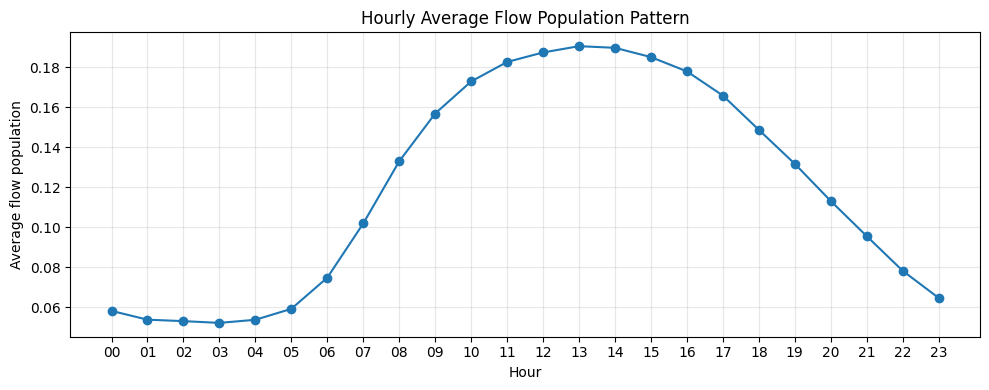

저장 완료: ../outputs/figures/flow_hourly_pattern.png


In [ ]:
# 시간대별 평균 패턴 시각화
# 시간대별 평균 유동인구 패턴

hourly_pattern = df_flow[tmst_cols].mean()

plt.figure(figsize=(10, 4))
hourly_pattern.plot(marker="o")
plt.title("Hourly Average Flow Population Pattern")
plt.xlabel("Hour")
plt.ylabel("Average flow population")
plt.xticks(range(24), [f"{i:02d}" for i in range(24)])
plt.grid(alpha=0.3)
plt.tight_layout()

save_fp = os.path.join(FIG_DIR, "flow_hourly_pattern.png")
plt.savefig(save_fp, dpi=300)
plt.show()

print("저장 완료:", save_fp)

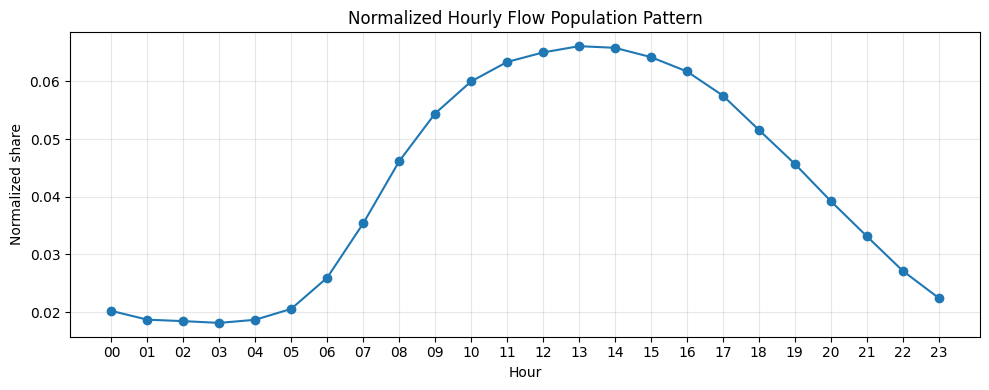

저장 완료: ../outputs/figures/flow_hourly_pattern_normalized.png


In [ ]:
# 시간대별 패턴 정규화 시각화

# 시간대별 패턴 정규화
normalized_pattern = hourly_pattern / hourly_pattern.sum()

plt.figure(figsize=(10, 4))
normalized_pattern.plot(marker="o")
plt.title("Normalized Hourly Flow Population Pattern")
plt.xlabel("Hour")
plt.ylabel("Normalized share")
plt.xticks(range(24), [f"{i:02d}" for i in range(24)])
plt.grid(alpha=0.3)
plt.tight_layout()

save_fp = os.path.join(FIG_DIR, "flow_hourly_pattern_normalized.png")
plt.savefig(save_fp, dpi=300)
plt.show()

print("저장 완료:", save_fp)

### 시간대별 유동인구 패턴 분석

직장인구와 방문인구를 통합하여 생성한 유동인구 데이터의 시간대별 평균 패턴을 확인
- 전체 합으로 정규화한 패턴을 통해, 절대 규모 뿐 아니라 하루 중 어느 시간대가 인구가 상대적으로 집중되는지 파악이 가능함.

In [ ]:
# 시간대 구간별 유동인구 변수 생성

df_flow["flow_0005"] = df_flow[[f"TMST_{i:02d}" for i in range(0, 6)]].sum(axis=1)
df_flow["flow_0609"] = df_flow[[f"TMST_{i:02d}" for i in range(6, 10)]].sum(axis=1)
df_flow["flow_1016"] = df_flow[[f"TMST_{i:02d}" for i in range(10, 17)]].sum(axis=1)
df_flow["flow_1720"] = df_flow[[f"TMST_{i:02d}" for i in range(17, 21)]].sum(axis=1)
df_flow["flow_2123"] = df_flow[[f"TMST_{i:02d}" for i in range(21, 24)]].sum(axis=1)

display(df_flow.head())

,gbn,STD_YM,lon,lat,gid,TMST_00,TMST_01,TMST_02,TMST_03,TMST_04,...,TMST_19,TMST_20,TMST_21,TMST_22,TMST_23,flow_0005,flow_0609,flow_1016,flow_1720,flow_2123
0,경기도 성남시,202401,127.027716,37.372890,다사581305,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.016333,0.034167,0.0045,0.0
1,경기도 성남시,202401,127.028272,37.374244,다사582306,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.030000,0.048333,0.0000,0.0
2,경기도 성남시,202401,127.028275,37.373793,다사582306,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.008333,0.025000,0.0050,0.0
3,경기도 성남시,202401,127.028278,37.373343,다사582305,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.016333,0.034167,0.0045,0.0
4,경기도 성남시,202401,127.028281,37.372892,다사582305,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.008333,0.025000,0.0050,0.0


In [ ]:
# 전처리 결과 56._시간대별 유동인구 생성

save_fp = os.path.join(OUT_DIR, "56._시간대별_유동인구.csv")

df_flow.to_csv(
    save_fp,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", save_fp)
print("최종 shape:", df_flow.shape)

저장 완료: ../outputs/processed/56._시간대별_유동인구.csv
최종 shape: (2980097, 34)


### 시간대별 유동인구 생성

직장인구 데이터, 방문인구 데이터는 모두 특정 위치에서 시간대별 인구를 나타냄.
직장인구는 업무 활동 기반 인구, 방문인구는 외부 유입 기반 활동 인구를 반영

- 두 데이터 통합으로 해당 지역의 실질적인 시간대별 유동인구 규모를 보다 현실적으로 반영할 수 있음.

**시간대 구간별 유동인구 변수 생성**

- `flow_0005` : 새벽 시간대 (00~05시)
- `flow_0609` : 출근 시간대 (06~09시)
- `flow_1016` : 주간 활동 시간대 (10~16시)
- `flow_1720` : 퇴근 및 저녁 시간대 (17~20시)
- `flow_2123` : 야간 시간대 (21~23시)
    
추후에 있을 교통사고 위험 분석에서 설명 가능성과 모델 활용성을 높이기 위한 목적

# 07._주중주말_서비스인구.csv

데이터 설명:

- 특정 위치에서 주중/주말 구분에 따른 서비스 인구를 제공하는 데이터셋
- 해당 지역에서 실제로 활동하는 인구를 반영하는 지표로 직장/방문 인구를 포함한 생활권 기반 활동 인구의 특성을 설명 가능

교통사고 위험은 요일 특성에 따라 달라질 수 있음.
주중에는 출퇴근 및 업무 활동으로 인해 특정 지역의 차량 통행과 보행 활동이 증가할 수 있음
주말에는 상업시설, 여가시설, 공원 등으로의 방문 수요가 집중될 수 있음.

In [ ]:
DATA_DIR = "../dataset"
OUT_DIR = "../outputs/processed"
FIG_DIR = "../outputs/figures"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

file_07 = os.path.join(DATA_DIR, "07._주중주말_서비스인구.csv")

df_07 = pd.read_csv(
    file_07,
    encoding="utf-8",
    engine="python"
)

print("shape:", df_07.shape)
display(df_07.head())

shape: (5401157, 7)


,gbn,STD_YM,hw,w_pop,v_pop,lon,lat
0,경기도 성남시,202401,H,0.000714,0.000306,127.031674,37.372004
1,경기도 성남시,202401,H,0.000484,0.000914,127.032242,37.371556
2,경기도 성남시,202401,H,0.001604,0.002832,127.032239,37.372006
3,경기도 성남시,202401,H,0.002697,0.005008,127.032807,37.371558
4,경기도 성남시,202401,H,0.002703,0.005008,127.032804,37.372009


In [ ]:
# 결측치 확인하기

print("컬럼별 결측치 개수")
print(df_07.isna().sum())

컬럼별 결측치 개수
gbn       0
STD_YM    0
hw        0
w_pop     0
v_pop     0
lon       0
lat       0
dtype: int64


In [ ]:
# 점 데이터를 GeoDataFrame으로 변환하기

gdf_07 = gpd.GeoDataFrame(
    df_07,
    geometry=gpd.points_from_xy(df_07["lon"], df_07["lat"]),
    crs="EPSG:4326"
)

display(gdf_07.head())

# 격자 불러오기
grid_fp = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
grid = gpd.read_file(grid_fp)

print("grid shape:", grid.shape)
print("grid crs:", grid.crs)
display(grid.head())

,gbn,STD_YM,hw,w_pop,v_pop,lon,lat,geometry
0,경기도 성남시,202401,H,0.000714,0.000306,127.031674,37.372004,POINT (127.03167 37.37200)
1,경기도 성남시,202401,H,0.000484,0.000914,127.032242,37.371556,POINT (127.03224 37.37156)
2,경기도 성남시,202401,H,0.001604,0.002832,127.032239,37.372006,POINT (127.03224 37.37201)
3,경기도 성남시,202401,H,0.002697,0.005008,127.032807,37.371558,POINT (127.03281 37.37156)
4,경기도 성남시,202401,H,0.002703,0.005008,127.032804,37.372009,POINT (127.03280 37.37201)


grid shape: (99323, 4)
grid crs: EPSG:4326


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,2024,경기도 성남시,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,2024,경기도 성남시,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,2024,경기도 성남시,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."


In [ ]:
# Spatial Join으로 gid 부여하기

gdf_07_joined = gpd.sjoin(
    gdf_07,
    grid[["gid", "geometry"]],
    how="left",
    predicate="within"
)

print("within 기준 gid 결측:", gdf_07_joined["gid"].isna().sum())

df_07_gid = (
    gdf_07_joined
    .drop(columns=["index_right"], errors="ignore")
    .drop(columns=["geometry"], errors="ignore")
)

display(df_07_gid.head())

within 기준 gid 결측: 138838


,gbn,STD_YM,hw,w_pop,v_pop,lon,lat,gid
0,경기도 성남시,202401,H,0.000714,0.000306,127.031674,37.372004,다사585304
1,경기도 성남시,202401,H,0.000484,0.000914,127.032242,37.371556,다사585303
2,경기도 성남시,202401,H,0.001604,0.002832,127.032239,37.372006,다사585304
3,경기도 성남시,202401,H,0.002697,0.005008,127.032807,37.371558,다사586303
4,경기도 성남시,202401,H,0.002703,0.005008,127.032804,37.372009,다사586304


intersects 기준 gid 결측: 138838


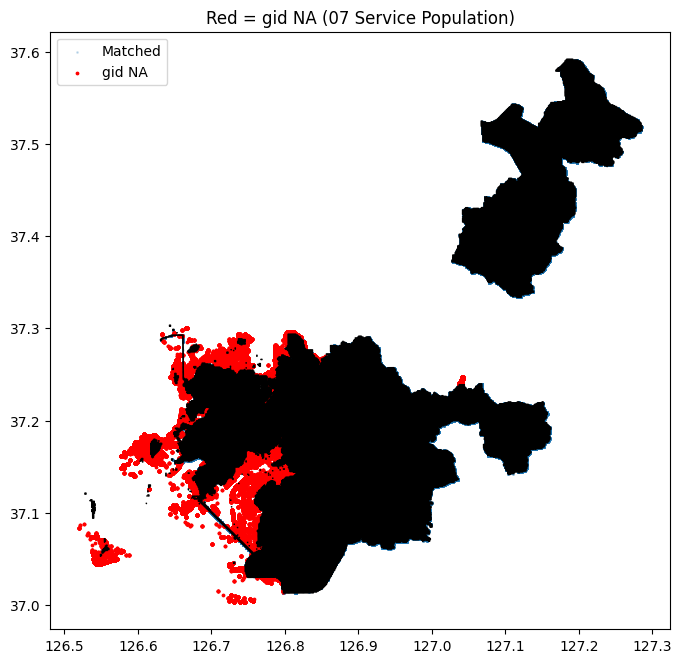

저장 완료: ../outputs/figures/07_service_population_gid_check.png


In [ ]:
# intersects 기준 재확인
gdf_07_joined2 = gpd.sjoin(
    gdf_07,
    grid[["gid", "geometry"]],
    how="left",
    predicate="intersects"
)

print("intersects 기준 gid 결측:", gdf_07_joined2["gid"].isna().sum())

#공간 매핑 결과 시각화
# gid NA / 정상 분리
na_07 = gdf_07_joined[gdf_07_joined["gid"].isna()]
ok_07 = gdf_07_joined[~gdf_07_joined["gid"].isna()]

fig, ax = plt.subplots(figsize=(8, 8))

# 격자 경계
grid.boundary.plot(ax=ax, color="black", linewidth=0.5)

# 정상 매핑 점
ok_07.plot(ax=ax, markersize=1, alpha=0.2, label="Matched")

# gid NA 점
na_07.plot(ax=ax, color="red", markersize=3, label="gid NA")

plt.title("Red = gid NA (07 Service Population)")
plt.legend()

save_fp = os.path.join(FIG_DIR, "07_service_population_gid_check.png")
plt.savefig(save_fp, dpi=300)
plt.show()

print("저장 완료:", save_fp)

In [ ]:
# gid 없는 데이터 제거 & 필요한 컬럼만 사용
df_07_gid = df_07_gid[~df_07_gid["gid"].isna()].copy()

print("gid 부여 후 유지 행 수:", len(df_07_gid))
display(df_07_gid.head())

# pivot 전에 필요한 컬럼만 선택
df_07_re = df_07_gid[["gid", "STD_YM", "gbn", "hw", "w_pop", "v_pop"]].copy()

display(df_07_re.head())
df_07_pivot = (
    df_07_re
    .pivot_table(
        index=["gid", "STD_YM", "gbn"],
        columns="hw",
        values=["w_pop", "v_pop"]
    )
)

# 컬럼 이름 정리
df_07_pivot.columns = [
    f"{'weekday' if hw == 'H' else 'weekend'}_{pop}"
    for pop, hw in df_07_pivot.columns
]

df_07_pivot = df_07_pivot.reset_index()

display(df_07_pivot.head())

gid 부여 후 유지 행 수: 5278767


,gbn,STD_YM,hw,w_pop,v_pop,lon,lat,gid
0,경기도 성남시,202401,H,0.000714,0.000306,127.031674,37.372004,다사585304
1,경기도 성남시,202401,H,0.000484,0.000914,127.032242,37.371556,다사585303
2,경기도 성남시,202401,H,0.001604,0.002832,127.032239,37.372006,다사585304
3,경기도 성남시,202401,H,0.002697,0.005008,127.032807,37.371558,다사586303
4,경기도 성남시,202401,H,0.002703,0.005008,127.032804,37.372009,다사586304


,gid,STD_YM,gbn,hw,w_pop,v_pop
0,다사585304,202401,경기도 성남시,H,0.000714,0.000306
1,다사585303,202401,경기도 성남시,H,0.000484,0.000914
2,다사585304,202401,경기도 성남시,H,0.001604,0.002832
3,다사586303,202401,경기도 성남시,H,0.002697,0.005008
4,다사586304,202401,경기도 성남시,H,0.002703,0.005008


,gid,STD_YM,gbn,weekday_v_pop,weekend_v_pop,weekday_w_pop,weekend_w_pop
0,다바154953,202401,경기도 화성시,0.007087,0.0000,0.001748,0.0030
1,다바154953,202402,경기도 화성시,0.008293,0.0000,0.003902,0.0000
2,다바154953,202403,경기도 화성시,0.010285,0.0008,0.001036,0.0032
3,다바154953,202404,경기도 화성시,0.010453,0.0025,0.000049,0.0000
4,다바154953,202405,경기도 화성시,0.010144,0.0050,0.000000,0.0000


In [ ]:
# 총합 변수 생성 후 저장하기

# 직장인구 총합
df_07_pivot["w_total"] = (
    df_07_pivot["weekday_w_pop"] +
    df_07_pivot["weekend_w_pop"]
)

# 방문인구 총합
df_07_pivot["v_total"] = (
    df_07_pivot["weekday_v_pop"] +
    df_07_pivot["weekend_v_pop"]
)

display(
    df_07_pivot[[
        "weekday_w_pop", "weekend_w_pop", "w_total",
        "weekday_v_pop", "weekend_v_pop", "v_total"
    ]].head()
)

display(df_07_pivot.head())

save_fp = os.path.join(OUT_DIR, "07_service_population_processed.csv")

df_07_pivot.to_csv(
    save_fp,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", save_fp)
print("최종 shape:", df_07_pivot.shape)

,weekday_w_pop,weekend_w_pop,w_total,weekday_v_pop,weekend_v_pop,v_total
0,0.001748,0.0030,0.004748,0.007087,0.0000,0.007087
1,0.003902,0.0000,0.003902,0.008293,0.0000,0.008293
2,0.001036,0.0032,0.004236,0.010285,0.0008,0.011085
3,0.000049,0.0000,0.000049,0.010453,0.0025,0.012953
4,0.000000,0.0000,0.000000,0.010144,0.0050,0.015144


,gid,STD_YM,gbn,weekday_v_pop,weekend_v_pop,weekday_w_pop,weekend_w_pop,w_total,v_total
0,다바154953,202401,경기도 화성시,0.007087,0.0000,0.001748,0.0030,0.004748,0.007087
1,다바154953,202402,경기도 화성시,0.008293,0.0000,0.003902,0.0000,0.003902,0.008293
2,다바154953,202403,경기도 화성시,0.010285,0.0008,0.001036,0.0032,0.004236,0.011085
3,다바154953,202404,경기도 화성시,0.010453,0.0025,0.000049,0.0000,0.000049,0.012953
4,다바154953,202405,경기도 화성시,0.010144,0.0050,0.000000,0.0000,0.000000,0.015144


저장 완료: ../outputs/processed/07_service_population_processed.csv
최종 shape: (922573, 9)


### 7번 서비스 인구 데이터 전처리

마찬가지로 서비스 인구 데이터를 포함한 데이터를 포함한 점 기반 데이터
또한 `hw` 변수를 기준으로 주중(`H`)과 주말(`W`) 데이터를 구분 -> pivot 형태로 재구성

아래와 같은 단위 변수들을 생성:

- `weekday_w_pop` : 주중 직장인구
- `weekend_w_pop` : 주말 직장인구
- `weekday_v_pop` : 주중 방문인구
- `weekend_v_pop` : 주말 방문인구
- `w_total` : 전체 직장인구 합계
- `v_total` : 전체 방문인구 합계

주중/주말 활동 인구 특성을 반영하는 설명 변수로 활용

In [ ]:
# 8번 데이터셋 상세도로망_네트워크 파악하기

DATA_DIR = "../dataset"

road_fp = os.path.join(DATA_DIR, "08.상세도로망_네트워크.geojson")

road = gpd.read_file(road_fp)

print("\n================ ROAD NETWORK (08) ================")
print("shape:", road.shape)
print("CRS:", road.crs)

print("\ncolumns:")
print(road.columns.tolist())

print("\ngeometry type:")
print(road.geometry.geom_type.value_counts())

print("\nhead:")
display(road.head())

print("\nNull check:")
check_cols = [c for c in ["up_v_link", "dw_v_link"] if c in road.columns]
if len(check_cols) > 0:
    print(road[check_cols].isnull().sum())
else:
    print("up_v_link / dw_v_link 컬럼 없음")

if "k_length" in road.columns:
    print("\nRoad length summary (k_length):")
    display(road["k_length"].describe())
elif "length" in road.columns:
    print("\nRoad length summary (length):")
    display(road["length"].describe())

print("\n전체 bounds:")
print(road.total_bounds)


================ ROAD NETWORK (08) ================
shape: (24003, 35)
CRS: EPSG:4326

columns:
['link_id', 'up_f_node', 'up_t_node', 'dw_f_node', 'dw_t_node', 'max_speed', 'road_name', 'road_no', 'road_rank', 'link_type', 'pavement', 'road_type', 'facil_name', 'tg_name', 'up_lanes', 'dw_lanes', 'lanes', 'oneway', 'length', 'level', 'up_its_id', 'dw_its_id', 'sido_id', 'sigungu_id', 'emd_id', 'up_v_link', 'dw_v_link', 'm_date', 'rc_id', 'rc_name', 'rc_hist', 'rc_date', 'rc_length', 'old_link_i', 'geometry']

geometry type:
LineString    24003
Name: count, dtype: int64

head:


,link_id,up_f_node,up_t_node,dw_f_node,dw_t_node,max_speed,road_name,road_no,road_rank,link_type,...,up_v_link,dw_v_link,m_date,rc_id,rc_name,rc_hist,rc_date,rc_length,old_link_i,geometry
0,475200018,181435,181436,181436,181435,40,해안길,0,107,32768,...,47520001801,47520001802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61802 37.16365, 126.61934 37.1..."
1,475200026,181436,181444,181444,181436,40,해안길178번길,0,107,32768,...,47520002601,47520002602,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61934 37.16377, 126.61940 37.1..."
2,475200028,181437,181438,181438,181437,40,None,0,107,32768,...,47520002801,47520002802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61722 37.1..."
3,475200030,181517,181437,181437,181517,40,해안길178번길,0,107,32768,...,47520003001,47520003002,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61825 37.17026, 126.61842 37.1..."
4,475200032,181437,181440,181440,181437,40,해안길178번길,0,107,32768,...,47520003201,47520003202,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61862 37.1..."



Null check:
up_v_link    0
dw_v_link    0
dtype: int64

Road length summary (length):


count    24003.000000
mean         0.144148
std          0.271240
min          0.004000
25%          0.032000
50%          0.064000
75%          0.157000
max          8.398000
Name: length, dtype: float64


전체 bounds:
[126.61697902  37.00807817 127.28461166  37.59000904]


# 08.상세도로망_네트워크.geojson

데이터 설명:
4개 도시의 도로 링크(link) 정보를 포함하는 공간 데이터, 본 연구에서 교통 특성을 설명하는 핵심 기반 데이터
각 도로는 선형형태의 geometry를 가지며,이후 평균속도, 추정교통량, 혼잡빈도강고, 혼잡시간강도와 같은 링크 단위 교통 데이터와 연결되는역할

본 단계에서 상세 도로망 네트워크의 기본 구조를 확인하기 위하여 다음을 확인하였음.

- 데이터 크기, 좌표계, geometry 타입
- 주요 링크 식별 컬럼 존재 여부, 도로 길이 관련 변수 분포, 공간 범위

In [ ]:
# 9번부터 13번 데이터셋 (교통량 + 사고 데이터 총합 분석)

DATA_DIR = "../dataset"

SPEED_PATH   = os.path.join(DATA_DIR, "09._평균속도.csv")
TRAFFIC_PATH = os.path.join(DATA_DIR, "10._추정교통량.csv")
CF_PATH      = os.path.join(DATA_DIR, "11._혼잡빈도강도.csv")
CT_PATH      = os.path.join(DATA_DIR, "12._혼잡시간강도.csv")
ACC_PATH     = os.path.join(DATA_DIR, "13._교통사고이력.geojson")


# 공통 CSV 검사 함수
def audit_link_csv(path, name):
    print(f"\n================ {name} ================")

    df = pd.read_csv(path, encoding="utf-8-sig")
    print("shape:", df.shape)

    print("\ncolumns:")
    print(df.columns.tolist())

    print("\ndtypes:")
    print(df.dtypes)

    print("\nNull ratio (%):")
    print((df.isnull().mean() * 100).sort_values(ascending=False).head(10))

    if "v_link_id" in df.columns:
        print("\nUnique v_link_id:", df["v_link_id"].nunique())

        dup_ratio = df.duplicated(subset=["v_link_id"]).mean()
        print("Duplicate ratio on v_link_id:", dup_ratio)

        if "timeslot" in df.columns:
            dup_pair = df.duplicated(subset=["v_link_id", "timeslot"]).sum()
            print("Duplicate count on (v_link_id, timeslot):", dup_pair)

            print("Timeslot unique:", sorted(df["timeslot"].dropna().unique()))
            print("Timeslot min/max:", df["timeslot"].min(), df["timeslot"].max())

    numeric_cols = df.select_dtypes(include=np.number).columns

    # 음수값 검사
    for col in numeric_cols:
        if (df[col] < 0).any():
            print(f"Negative values found in {col}")

    # 대표 컬럼 이상치 비율(IQR)
    for col in numeric_cols[:3]:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        outliers = (df[col] > upper).mean()
        print(f"IQR outlier ratio ({col}): {outliers:.4f}")

    display(df.head())
    return df


# 09~12 검사
df_speed   = audit_link_csv(SPEED_PATH,   "09 평균속도")
df_traffic = audit_link_csv(TRAFFIC_PATH, "10 추정교통량")
df_cf      = audit_link_csv(CF_PATH,      "11 혼잡빈도강도")
df_ct      = audit_link_csv(CT_PATH,      "12 혼잡시간강도")

# 13 사고 데이터 검사
print("\n================ ACCIDENT (13) ================")

acc = gpd.read_file(ACC_PATH)

print("shape:", acc.shape)
print("CRS:", acc.crs)

print("\ncolumns:")
print(acc.columns.tolist())

print("\ngeometry type:")
print(acc.geometry.geom_type.value_counts())

print("\nNull geometry:", acc.geometry.isnull().sum())

dup_geom = acc.duplicated(subset=["geometry"]).sum()
print("Duplicate geometry count:", dup_geom)

print("\nAccident bbox:")
print(acc.total_bounds)

display(acc.head())


================ 09 평균속도 ================
shape: (926518, 12)

columns:
['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'velocity_AVRG', 'probe']

dtypes:
v_link_id          int64
road_rank          int64
k_length         float64
sido_id            int64
sigungu_id         int64
emd_id             int64
sido_name         object
sigungu_name      object
emd_name          object
timeslot           int64
velocity_AVRG    float64
probe              int64
dtype: object

Null ratio (%):
v_link_id       0.0
road_rank       0.0
k_length        0.0
sido_id         0.0
sigungu_id      0.0
emd_id          0.0
sido_name       0.0
sigungu_name    0.0
emd_name        0.0
timeslot        0.0
dtype: float64

Unique v_link_id: 40036
Duplicate ratio on v_link_id: 0.9567887510010599
Duplicate count on (v_link_id, timeslot): 0
Timeslot unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2

,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,sido_name,sigungu_name,emd_name,timeslot,velocity_AVRG,probe
0,57166862101,104,1.320,11000,11240,11240820,서울특별시,송파구,위례동,0,63.87,2725
1,57166862102,104,1.320,11000,11240,11240820,서울특별시,송파구,위례동,0,48.48,4926
2,57164847201,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,30.31,438
3,57164847202,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,27.97,915
4,57177182401,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,29.83,2692



================ 10 추정교통량 ================
shape: (926518, 14)

columns:
['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'ALL_AADT', 'PSCR_AADT', 'BUS_AADT', 'FGCR_AADT']

dtypes:
v_link_id         int64
road_rank         int64
k_length        float64
sido_id           int64
sigungu_id        int64
emd_id            int64
sido_name        object
sigungu_name     object
emd_name         object
timeslot          int64
ALL_AADT          int64
PSCR_AADT         int64
BUS_AADT          int64
FGCR_AADT         int64
dtype: object

Null ratio (%):
v_link_id       0.0
road_rank       0.0
k_length        0.0
sido_id         0.0
sigungu_id      0.0
emd_id          0.0
sido_name       0.0
sigungu_name    0.0
emd_name        0.0
timeslot        0.0
dtype: float64

Unique v_link_id: 40036
Duplicate ratio on v_link_id: 0.9567887510010599
Duplicate count on (v_link_id, timeslot): 0
Timeslot unique: [0, 1, 2, 3, 4, 5, 6, 7

,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,sido_name,sigungu_name,emd_name,timeslot,ALL_AADT,PSCR_AADT,BUS_AADT,FGCR_AADT
0,57166862101,104,1.320,11000,11240,11240820,서울특별시,송파구,위례동,0,331,236,5,89
1,57166862102,104,1.320,11000,11240,11240820,서울특별시,송파구,위례동,0,564,457,5,103
2,57164847201,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,158,137,2,19
3,57164847202,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,179,159,3,17
4,57177182401,104,0.017,11000,11240,11240710,서울특별시,송파구,잠실본동,0,434,383,10,41



================ 11 혼잡빈도강도 ================
shape: (39451, 10)

columns:
['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'FRIN_CG']

dtypes:
v_link_id         int64
road_rank         int64
k_length        float64
sido_id           int64
sigungu_id        int64
emd_id            int64
sido_name        object
sigungu_name     object
emd_name         object
FRIN_CG         float64
dtype: object

Null ratio (%):
v_link_id       0.0
road_rank       0.0
k_length        0.0
sido_id         0.0
sigungu_id      0.0
emd_id          0.0
sido_name       0.0
sigungu_name    0.0
emd_name        0.0
FRIN_CG         0.0
dtype: float64

Unique v_link_id: 39451
Duplicate ratio on v_link_id: 0.0
IQR outlier ratio (v_link_id): 0.0212
IQR outlier ratio (road_rank): 0.0000
IQR outlier ratio (k_length): 0.0862


,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,sido_name,sigungu_name,emd_name,FRIN_CG
0,57155811401,102,0.088,31000,31021,31021660,경기도,성남시수정구,시흥동,57.05
1,57275538101,107,0.031,31000,31180,31180560,경기도,하남시,덕풍3동,28.93
2,57134792701,107,0.035,31000,31240,31240620,경기도,화성시,동탄3동,93.85
3,57139008401,107,0.037,31000,31240,31240570,경기도,화성시,화산동,18.05
4,57166297201,104,0.422,11000,11240,11240690,서울특별시,송파구,문정2동,13.46



================ 12 혼잡시간강도 ================
shape: (39451, 10)

columns:
['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'TI_CG']

dtypes:
v_link_id         int64
road_rank         int64
k_length        float64
sido_id           int64
sigungu_id        int64
emd_id            int64
sido_name        object
sigungu_name     object
emd_name         object
TI_CG           float64
dtype: object

Null ratio (%):
v_link_id       0.0
road_rank       0.0
k_length        0.0
sido_id         0.0
sigungu_id      0.0
emd_id          0.0
sido_name       0.0
sigungu_name    0.0
emd_name        0.0
TI_CG           0.0
dtype: float64

Unique v_link_id: 39451
Duplicate ratio on v_link_id: 0.0
IQR outlier ratio (v_link_id): 0.0212
IQR outlier ratio (road_rank): 0.0000
IQR outlier ratio (k_length): 0.0862


,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,sido_name,sigungu_name,emd_name,TI_CG
0,47714279201,107,0.496,31000,31240,31240390,경기도,화성시,장안면,11.24
1,57134681402,107,0.073,31000,31240,31240610,경기도,화성시,동탄1동,91.27
2,57164853302,104,0.029,11000,11240,11240620,서울특별시,송파구,송파2동,92.66
3,57168287801,104,0.167,11000,11240,11240660,서울특별시,송파구,가락1동,33.37
4,57154330602,107,0.112,31000,31021,31021660,경기도,성남시수정구,시흥동,98.19



================ ACCIDENT (13) ================
shape: (10821, 19)
CRS: EPSG:4326

columns:
['acc_yr', 'acc_mon', 'week_type', 'acc_time', 'sgg', 'acc_type', 'violation', 'road_type', 'road_sttus', 'weather', 'attckr_vhcle', 'victim_vhcle', 'injury_svrity', 'age_group', 'dprs_cnt', 'sep_cnt', 'slp_cnt', 'inj_aplcnt_cnt', 'geometry']

geometry type:
Point    10821
Name: count, dtype: int64

Null geometry: 0
Duplicate geometry count: 12

Accident bbox:
[126.62178359  37.02542705 127.28320631  37.58424054]


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,경상,41-50세,0,0,1,0,POINT (127.13635 37.37966)
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,부상신고,41-50세,0,0,0,1,POINT (127.12005 37.34924)
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,승합,승용,상해없음,51-60세,0,1,0,0,POINT (127.13826 37.40957)
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,승용,승용,중상,31-40세,0,1,0,0,POINT (127.10030 37.39987)
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,승용,승용,경상,31-40세,0,0,1,0,POINT (127.10431 37.40320)


# 9~13번 데이터셋 진단

8번 상세도로망 네트워크를 기준으로 이후 링크 단위 교통 변수와 사고 데이터를 연결하기 위해 9~13번 데이터 분석

각 데이터셋의 역할

- **09._평균속도.csv** : 링크 단위 평균속도 정보
- **10._추정교통량.csv** : 링크 단위 교통량 정보
- **11._혼잡빈도강도.csv** : 링크 단위 혼잡 빈도 강도
- **12._혼잡시간강도.csv** : 링크 단위 혼잡 시간 강도
- **13._교통사고이력.geojson** : 사고 발생 위치 정보

본 단계에서는 아래의 정보들을 확인하고, 추후에 데이터셋을 자세히 검정함.

- 데이터 크기(shape)
- 컬럼 구조 및 자료형
- 결측치 비율
- 링크 식별자(`v_link_id`)의 중복 여부
- 시간대(`timeslot`) 변수의 범위 및 유효성
- 음수값 존재 여부
- 주요 수치 변수의 이상치 비율
- 사고 데이터의 geometry 유효성 및 공간 범위


## 12._혼잡시간강도.csv

데이터 소개:

- 도로 링크 단위의 혼잡시간강도 정보를 제공하는 데이터
- 혼잡시간강도 : 특정 도로 구간에서 교통 혼잡이 얼마나 오래 지속되는지를 정량적으로 나타내는 지표, 단순 통행량이나 평균속도와는 다른 **교통 운영 상태의 질적 특성**을 반영

In [ ]:
DATA_DIR = "../dataset"
PATH_12 = os.path.join(DATA_DIR, "12._혼잡시간강도.csv")

df12 = pd.read_csv(PATH_12, encoding="utf-8-sig")

print("shape:", df12.shape)
print("cols:", df12.columns.tolist())

print("\n[dtypes]")
print(df12.dtypes)

# 1) 결측치 및 기초 통계
null_ratio = df12.isna().mean().sort_values(ascending=False)
print("\n[null ratio top]")
print(null_ratio.head(15))

num_cols = df12.select_dtypes(include=[np.number]).columns
print("\n[describe numeric]")
display(df12[num_cols].describe().T)

# 2) 키 / 중복 점검
key = ["v_link_id"]
dup_cnt = df12.duplicated(subset=key).sum()

print("\n[dup check]")
print("dup on v_link_id:", dup_cnt)

print("\n[v_link_id validity]")
print("v_link_id <= 0:", (df12["v_link_id"] <= 0).sum())

# 3) 값 범위 점검 (TI_CG)
target = "TI_CG"

print("\n[TI_CG range]")
print("min/max:", df12[target].min(), df12[target].max())
print("neg count:", (df12[target] < 0).sum())
print("zero count:", (df12[target] == 0).sum())

# 4) 이상치 점검 (IQR, robust z-score)
q1, q3 = df12[target].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

out_iqr = df12[(df12[target] < low) | (df12[target] > high)]

print("\n[IQR outlier]")
print("low/high:", low, high)
print("outlier rows:", len(out_iqr))

median = df12[target].median()
mad = (df12[target] - median).abs().median()

if mad == 0:
    print("\n[MAD] mad=0 so robust z-score skipped")
else:
    rz = 0.6745 * (df12[target] - median) / mad
    out_rz = df12[rz.abs() > 5]
    print("\n[robust z-score |rz|>5]")
    print("rows:", len(out_rz))

# 5) 행정코드-명칭 일관성 점검
def one_to_many_check(df, code_col, name_col, topn=10):
    g = df.groupby(code_col)[name_col].nunique().sort_values(ascending=False)
    bad = g[g > 1]

    print(f"\n[one-to-many] {code_col} -> {name_col} (nunique > 1):", len(bad))

    if len(bad):
        print(bad.head(topn))
        sample_codes = bad.head(min(5, len(bad))).index.tolist()
        print("\n[samples]")
        for c in sample_codes:
            print(c, df.loc[df[code_col] == c, name_col].dropna().unique()[:10])

one_to_many_check(df12, "sido_id", "sido_name")
one_to_many_check(df12, "sigungu_id", "sigungu_name")
one_to_many_check(df12, "emd_id", "emd_name")

# 6) 전처리 힌트 요약
print("\n[preprocess hints]")
hints = []

if (df12[target] < 0).any():
    hints.append("TI_CG negative -> clamp/remove needed")
if df12.isna().any().any():
    hints.append("has NA -> decide fill/drop")
if dup_cnt > 0:
    hints.append("dup on v_link_id -> dedup needed")

if len(hints) == 0:
    hints.append("No obvious cleaning needed; treat as static link feature")

print("- " + "\n- ".join(hints))

shape: (39451, 10)
cols: ['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'TI_CG']

[dtypes]
v_link_id         int64
road_rank         int64
k_length        float64
sido_id           int64
sigungu_id        int64
emd_id            int64
sido_name        object
sigungu_name     object
emd_name         object
TI_CG           float64
dtype: object

[null ratio top]
v_link_id       0.0
road_rank       0.0
k_length        0.0
sido_id         0.0
sigungu_id      0.0
emd_id          0.0
sido_name       0.0
sigungu_name    0.0
emd_name        0.0
TI_CG           0.0
dtype: float64

[describe numeric]


,count,mean,std,min,25%,50%,75%,max
v_link_id,39451.0,5.653819e+10,1.820895e+10,4.752000e+10,4.783418e+10,5.713869e+10,5.725485e+10,2.024003e+11
road_rank,39451.0,1.062644e+02,1.415217e+00,1.010000e+02,1.060000e+02,1.070000e+02,1.070000e+02,1.070000e+02
k_length,39451.0,1.399681e-01,2.560782e-01,4.000000e-03,3.300000e-02,6.600000e-02,1.520000e-01,8.398000e+00
sido_id,39451.0,2.889308e+04,6.140049e+03,1.100000e+04,3.100000e+04,3.100000e+04,3.100000e+04,3.100000e+04
sigungu_id,39451.0,2.906799e+04,6.118415e+03,1.124000e+04,3.102300e+04,3.124000e+04,3.124000e+04,3.124000e+04
emd_id,39451.0,2.906850e+07,6.118359e+06,1.124051e+07,3.102358e+07,3.124012e+07,3.124039e+07,3.124072e+07
TI_CG,39451.0,7.452627e+01,2.773313e+01,0.000000e+00,5.834500e+01,8.653000e+01,9.689000e+01,1.000000e+02



[dup check]
dup on v_link_id: 0

[v_link_id validity]
v_link_id <= 0: 0

[TI_CG range]
min/max: 0.0 100.0
neg count: 0
zero count: 9

[IQR outlier]
low/high: 0.5274999999999963 154.7075
outlier rows: 51

[robust z-score |rz|>5]
rows: 0

[one-to-many] sido_id -> sido_name (nunique > 1): 0

[one-to-many] sigungu_id -> sigungu_name (nunique > 1): 0

[one-to-many] emd_id -> emd_name (nunique > 1): 0

[preprocess hints]
- No obvious cleaning needed; treat as static link feature


## 12번 데이터셋 결과 해석

핵심 결과 : 전반적으로 품질이 매우 우수함 (전처리 필요X)

- 전체 행 수는 **39,451**개, 주요 컬럼 구조가 명확
- **결측치가 전혀 없음.**
- v_link_id 기준 중복이 없고, id가 음수인 이상치도 없음.
- TI_CG 값은 0~100 범위 내에 있어 값 범위가 합리적이였고, 0인 값도 9건으로 매우 작았음.
(IQR 기준 51건도 분포 특성상 이해할 수 있는 값으로 바로 활용 가능하다고 판단)

# 13._교통사고이력.geojson

데이터 설명:
사고 발생 위치와 사고 관련 속성을 얻는 포함하는 공간 데이터, **교통사고 발생 자체를 설명하는 핵심 타깃 데이터**

다음과 같은 분석을 수행

- 격자 단위 사고 건수 집계
- 사고 발생 여부(0/1) 생성
- hotspot 분석
- 교통 위험도 모델(Logit, NB)의 종속변수 생성
- CMF 추정 시 사고 발생 링크/격자 식별

In [ ]:
DATA_DIR = "../dataset"
PATH_13 = os.path.join(DATA_DIR, "13._교통사고이력.geojson")

# 데이터 로드
acc = gpd.read_file(PATH_13).to_crs("EPSG:4326")

print("rows:", len(acc))
print("geom null:", acc.geometry.isna().sum())
print("geom type:", acc.geometry.geom_type.value_counts().to_dict())

# 1) geometry를 WKT로 변환하여 완전히 동일한 geometry 그룹 확인
acc["geom_wkt"] = acc.geometry.to_wkt()

dup_mask = acc.duplicated(subset=["geom_wkt"], keep=False)
dup = acc.loc[dup_mask].copy()

print("\n[dup geometry groups]")
print("dup rows:", len(dup))
print("dup unique geometries:", dup["geom_wkt"].nunique())

# 2) 동일 geometry 그룹 내에서 어떤 컬럼이 다른지 비교
cols = acc.columns.tolist()
print("\n[columns]")
print(cols)

# 사고 관련 후보 컬럼 자동 탐색
cands = []
for c in cols:
    lc = str(c).lower()
    if any(k in lc for k in [
        "date", "time", "ymd", "day",
        "발생", "일자", "시간", "시각",
        "사고", "유형", "사상", "사망", "부상"
    ]):
        cands.append(c)

cands = cands[:15]
print("\n[candidate cols to compare]")
print(cands)

# 그룹별 후보 컬럼의 nunique 확인
if len(dup) > 0 and len(cands) > 0:
    summary = dup.groupby("geom_wkt")[cands].nunique(dropna=False)
    print("\n[group nunique summary (top)]")
    display(summary.head(10))
else:
    print("\n비교할 후보 컬럼이 없거나 중복 geometry가 없음")

# 3) 동일 geometry 샘플 확인
sample_geoms = dup["geom_wkt"].drop_duplicates().head(3).tolist()

for i, gw in enumerate(sample_geoms, 1):
    sub = dup[dup["geom_wkt"] == gw].copy()
    print(f"\n=== DUP GEOM GROUP #{i} (rows={len(sub)}) ===")

    show_cols = [c for c in sub.columns if c not in ["geometry", "geom_wkt"]][:20]
    display(sub[show_cols])

# 4) 전처리 판단 가이드
print("\n[preprocess guidance]")
print("- geometry만 동일한 건 '같은 위치에서 다른 사고'일 수 있어 단순 drop 위험")
print("- 만약 발생일시/사고유형/사상자 등까지 완전 동일하면 그때만 중복 제거 고려")

rows: 10821
geom null: 0
geom type: {'Point': 10821}

[dup geometry groups]
dup rows: 24
dup unique geometries: 12

[columns]
['acc_yr', 'acc_mon', 'week_type', 'acc_time', 'sgg', 'acc_type', 'violation', 'road_type', 'road_sttus', 'weather', 'attckr_vhcle', 'victim_vhcle', 'injury_svrity', 'age_group', 'dprs_cnt', 'sep_cnt', 'slp_cnt', 'inj_aplcnt_cnt', 'geometry', 'geom_wkt']

[candidate cols to compare]
['acc_time']

[group nunique summary (top)]


,acc_time
geom_wkt,
POINT (126.917739 37.118494),2
POINT (127.041645 37.19755),2
POINT (127.063476 37.212326),2
POINT (127.073362 37.208053),2
POINT (127.084211 37.387036),2
POINT (127.089671 37.201422),2
POINT (127.090334 37.507228),2
POINT (127.108616 37.514158),2
POINT (127.116848 37.386795),2



=== DUP GEOM GROUP #1 (rows=2) ===


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt
474,2024,4,주중,11시,경기도 성남시 분당구,차대차 - 추돌,안전거리미확보,교차로 - 교차로부근,건조,맑음,승용,화물,경상,51-60세,0,0,1,0
496,2024,4,주중,00시,경기도 성남시 분당구,차대차 - 충돌,신호위반,교차로 - 교차로안,기타,맑음,승용,승용,중상,31-40세,0,1,1,0



=== DUP GEOM GROUP #2 (rows=2) ===


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt
673,2024,6,주중,04시,경기도 성남시 분당구,차대차 - 기타,신호위반,교차로 - 교차로안,건조,맑음,승용,승용,경상,31-40세,0,1,1,0
1011,2024,8,주중,20시,경기도 성남시 분당구,차대차 - 기타,신호위반,교차로 - 교차로부근,건조,맑음,승합,승용,경상,31-40세,0,0,1,0



=== DUP GEOM GROUP #3 (rows=2) ===


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt
2344,2024,10,주말,09시,경기도 성남시 수정구,차대사람 - 기타,안전운전불이행,교차로 - 교차로부근,기타,맑음,승용,보행자,중상,65세 이상,0,1,0,0
2450,2024,11,주말,19시,경기도 성남시 수정구,차대사람 - 기타,안전운전불이행,단일로 - 기타,기타,맑음,승용,보행자,경상,51-60세,0,0,1,0



[preprocess guidance]
- geometry만 동일한 건 '같은 위치에서 다른 사고'일 수 있어 단순 drop 위험
- 만약 발생일시/사고유형/사상자 등까지 완전 동일하면 그때만 중복 제거 고려


### 13번 교통사고 데이터셋 동일 geometry 점검 결과

교통사고 이력 데이터에서 동일한 geometry를 가지는 사고 사례를 일부 확인
교통사고 동일한 위치에서 반복적으로 발생할 수 있기에, geometry가 같다는 이유만으로 단순 중복으로 간주하여 제거하는 것이 적절하지 않을 수 있음.

- 동일 geometry 그룹에 대해 사고 발생일 시, 사고유형, 사상자 관련 변수 등 주요 사고 속성이 서로 동일한지 비교


## 과산포 여부 진단 및 모델 선택 근거 확인

사고 건수 데이터는 일반적인 연속형 변수가 아니라 격자 단위의 count 데이터이기에 분포 특성에 따라 적절한 통계모형을 선택할 필요가 있음
실제 선행연구에서는 교통사고 건수와 같이 0이 많고 분산이 큰 자료에 대해, 평균과 분산이 동일하다고 가정하는 Poisson 모형보다 과산포 (over-dispersion)을 허용하는 Negative Binomial(NB) 모형이 더 적합한 경우가 많다고 보고

이에 따라 8~13번의 데이터셋 전처리 이후
사고 포인트 데이터를 4개 도시 격자에 대해 공간 결합을 진행하여 **격자별 사고건수를 산출 후, 도시별로 평균, 분산의 관계를 확인하고자 함**

ACC_PATH = ../dataset/13._교통사고이력.geojson
[GRID4 dedup] before=99323, after=99146, dup_gid_after=0
[ACC] geom types: {'Point': 10821} rows: 10821
[ACC] dup geometry rows: 12
[cities4] ['경기도 성남시', '경기도 하남시', '경기도 화성시', '서울특별시 송파구']
[SJOIN] predicate=within hit_rate=0.999908 miss=1 total=10821

[GRID COUNT sample]


,gid,city,acc_cnt
0,다사581304,경기도 성남시,0
1,다사581305,경기도 성남시,0
2,다사581306,경기도 성남시,0
3,다사582304,경기도 성남시,0
4,다사582305,경기도 성남시,0


/opt/conda/lib/python3.8/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '



================ Dispersion Summary by City ================


,city,n_grids,mean,var,dispersion_index(var/mean),zero_rate,max
0,경기도 성남시,14513,0.242334,0.935137,3.858870,0.882726,24.0
1,경기도 하남시,9589,0.122328,0.372498,3.045083,0.932944,15.0
2,경기도 화성시,71599,0.051621,0.137004,2.654044,0.966815,15.0
3,서울특별시 송파구,3445,0.706531,2.749798,3.891969,0.709144,20.0



================ Poisson vs NB (Intercept-only) ================


,city,poisson_aic,nb_aic,poisson_mu,nb_mu,nb_alpha
0,경기도 성남시,21380.269480,15238.923429,0.242334,0.242334,9.763196
1,경기도 하남시,8437.957730,6304.169790,0.122328,0.122328,15.078030
2,경기도 화성시,32166.446174,32168.435471,0.051621,0.051621,0.000002
3,서울특별시 송파구,10102.299436,7410.167167,0.706531,0.706531,3.827523



[Interpretation tips]
- dispersion_index(var/mean) > 1  => 과산포 경향 (NB 고려)
- dispersion_index(var/mean) ~ 1  => 포아송에 가까움
- dispersion_index(var/mean) < 1  => 저산포 경향
- zero_rate가 매우 높으면 zero-inflated( ZIP/ZINB )도 의심 가능
- AIC에서 NB가 충분히 낮으면 NB가 더 적합할 가능성이 큼


/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8

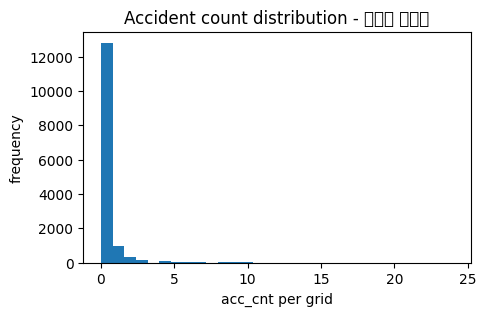

/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


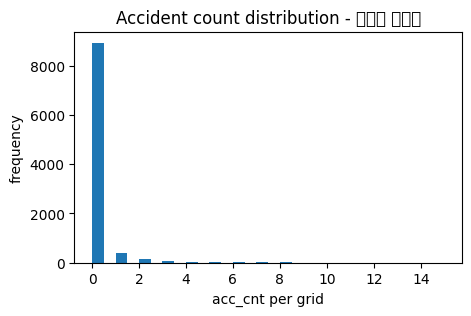

/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


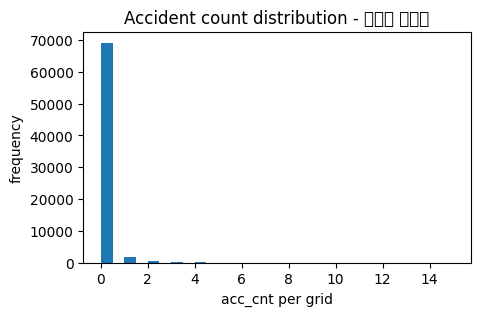

/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8

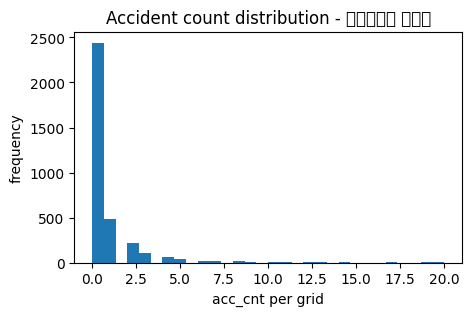

In [ ]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial


# 0) PATH 설정
DATA_DIR = "../dataset"

GRID4_PATH = os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson")
ACC_PATH   = os.path.join(DATA_DIR, "13._교통사고이력.geojson")

print("ACC_PATH =", ACC_PATH)


# 1) 유틸 함수
def load_grid4(path: str) -> gpd.GeoDataFrame:
    g = gpd.read_file(path)

    if "gid" not in g.columns:
        raise ValueError("Grid file must have 'gid' column.")

    # 도시 컬럼 통일
    if "gbn" in g.columns:
        g = g.rename(columns={"gbn": "city"})
    elif "city" not in g.columns:
        raise ValueError("Grid file must have 'gbn' or 'city' column.")

    # 필요한 컬럼만
    keep_cols = ["gid", "city", "geometry"]
    g = g[keep_cols].copy()

    # 중복 제거
    before = len(g)
    g = g.drop_duplicates(subset=["gid", "geometry"])
    after = len(g)
    dup_gid_after = g.duplicated(subset=["gid"]).sum()

    print(f"[GRID4 dedup] before={before}, after={after}, dup_gid_after={dup_gid_after}")

    # CRS 통일
    if g.crs is None:
        g = g.set_crs("EPSG:4326")
    else:
        g = g.to_crs("EPSG:4326")

    return g


def load_accident_geo(path: str) -> gpd.GeoDataFrame:
    a = gpd.read_file(path)

    if a.crs is None:
        a = a.set_crs("EPSG:4326")
    else:
        a = a.to_crs("EPSG:4326")

    if a.geometry.isna().any():
        print("[WARN] accident geometry has nulls -> dropping null geometries")
        a = a[~a.geometry.isna()].copy()

    geom_types = a.geometry.geom_type.value_counts().to_dict()
    print("[ACC] geom types:", geom_types, "rows:", len(a))

    # Point만 사용
    if "Point" in geom_types and len(geom_types) > 1:
        a = a[a.geometry.geom_type == "Point"].copy()

    dup_geom = a.duplicated(subset=["geometry"]).sum()
    print("[ACC] dup geometry rows:", int(dup_geom))

    return a


def grid_accident_counts(grid, acc, predicate="within"):
    joined = gpd.sjoin(
        acc,
        grid[["gid", "city", "geometry"]],
        how="left",
        predicate=predicate
    )

    miss = joined["gid"].isna().sum()
    total = len(joined)
    hit_rate = 1 - (miss / total)
    print(f"[SJOIN] predicate={predicate} hit_rate={hit_rate:.6f} miss={miss} total={total}")

    matched = joined.dropna(subset=["gid"]).copy()

    cnt = matched.groupby(["gid", "city"], as_index=False).size()
    cnt = cnt.rename(columns={"size": "acc_cnt"})

    universe = grid[["gid", "city"]].drop_duplicates()
    out = universe.merge(cnt, on=["gid", "city"], how="left")
    out["acc_cnt"] = out["acc_cnt"].fillna(0).astype(int)

    return out


def dispersion_summary(counts: pd.Series) -> dict:
    x = counts.astype(float).values
    mu = x.mean()
    var = x.var(ddof=1) if len(x) > 1 else 0.0
    di = (var / mu) if mu > 0 else np.nan
    zero_rate = (x == 0).mean()

    return {
        "n_grids": int(len(x)),
        "mean": float(mu),
        "var": float(var),
        "dispersion_index(var/mean)": float(di) if not np.isnan(di) else np.nan,
        "zero_rate": float(zero_rate),
        "max": float(x.max()) if len(x) else np.nan
    }


def fit_poisson_nb_intercept(counts: pd.Series) -> dict:
    y = counts.astype(int).values
    df = pd.DataFrame({"y": y, "const": 1.0})

    # Poisson GLM
    poi = sm.GLM(df["y"], df[["const"]], family=sm.families.Poisson()).fit()

    # NB (intercept only)
    try:
        nb = NegativeBinomial(df["y"], df[["const"]]).fit(disp=0)

        # 평균
        nb_mu = float(np.exp(nb.params.iloc[0]))

        # alpha 추출
        if "alpha" in nb.params.index:
            nb_alpha = float(nb.params["alpha"])
        elif hasattr(nb, "lnalpha"):
            nb_alpha = float(np.exp(nb.lnalpha))
        else:
            nb_alpha = np.nan

        nb_aic = float(nb.aic)

    except Exception as e:
        print("[WARN] NB fit failed:", e)
        nb_mu = np.nan
        nb_alpha = np.nan
        nb_aic = np.nan

    return {
        "poisson_aic": float(poi.aic),
        "poisson_mu": float(np.exp(poi.params["const"])),
        "nb_aic": nb_aic,
        "nb_mu": nb_mu,
        "nb_alpha": nb_alpha
    }


# 2) 로드
grid4 = load_grid4(GRID4_PATH)
acc   = load_accident_geo(ACC_PATH)

cities4 = sorted(grid4["city"].dropna().unique().tolist())
print("[cities4]", cities4)


# 3) 격자별 사고건수 생성
grid_cnt = grid_accident_counts(grid4, acc, predicate="within")

print("\n[GRID COUNT sample]")
display(grid_cnt.head())


# 4) 도시별 과산포 진단 + Poisson/NB 비교
rows = []
fit_rows = []

for c in cities4:
    sub = grid_cnt.loc[grid_cnt["city"] == c, "acc_cnt"]

    summ = dispersion_summary(sub)
    summ["city"] = c
    rows.append(summ)

    fit = fit_poisson_nb_intercept(sub)
    fit["city"] = c
    fit_rows.append(fit)

disp_df = pd.DataFrame(rows)[
    ["city", "n_grids", "mean", "var", "dispersion_index(var/mean)", "zero_rate", "max"]
].sort_values("city")

fit_df = pd.DataFrame(fit_rows)[
    ["city", "poisson_aic", "nb_aic", "poisson_mu", "nb_mu", "nb_alpha"]
].sort_values("city")

print("\n================ Dispersion Summary by City ================")
display(disp_df)

print("\n================ Poisson vs NB (Intercept-only) ================")
display(fit_df)

print("\n[Interpretation tips]")
print("- dispersion_index(var/mean) > 1  => 과산포 경향 (NB 고려)")
print("- dispersion_index(var/mean) ~ 1  => 포아송에 가까움")
print("- dispersion_index(var/mean) < 1  => 저산포 경향")
print("- zero_rate가 매우 높으면 zero-inflated( ZIP/ZINB )도 의심 가능")
print("- AIC에서 NB가 충분히 낮으면 NB가 더 적합할 가능성이 큼")


# 5) 도시별 히스토그램
for c in cities4:
    x = grid_cnt.loc[grid_cnt["city"] == c, "acc_cnt"].values
    plt.figure(figsize=(5, 3))
    plt.hist(x, bins=30)
    plt.title(f"Accident count distribution - {c}")
    plt.xlabel("acc_cnt per grid")
    plt.ylabel("frequency")
    plt.show()

### 격자별 사고건수의 과산포 진단 결과

도시별 격자 사고건수에 대해 평균과 분산의 관계를 비교한 결과 아래와 같은 결과가 나옴.

- **경기도 성남시** : 평균 0.242, 분산 0.935, 분산-평균비 3.86
- **경기도 하남시** : 평균 0.122, 분산 0.372, 분산-평균비 3.05
- **경기도 화성시** : 평균 0.052, 분산 0.137, 분산-평균비 2.65
- **서울특별시 송파구** : 평균 0.707, 분산 2.750, 분산-평균비 3.89

모든 도시에서 `variance / mean > 1` 이 확인되어, 사고건수 데이터는 전반적으로 Poisson 모형의 기본 가정인 `평균 = 분산` 을 만족하지 않음을 의미

**사고가 발생하지 않은 격자의 비율**도 매우 높게 나타남

- 성남시: 88.3%
- 하남시: 93.3%
- 화성시: 96.7%
- 송파구: 70.9%

하남시, 화성시는 대부분의 격자에서 사고가 0건으로 나타남.
-> 희소하고 0이 많은 count 데이터의 특성이 매우 강하게 나타남

- 이러한 결과는 이후 Zero-inflated 계열 모형 모혀에 대한 검토 가능성도 시사함.

실제 Possion 모형과 NB 모형의 AIC를 비교한 결과

- 성남시: Poisson AIC 21380.27 → NB AIC 15238.92
- 하남시: Poisson AIC 8437.96 → NB AIC 6304.17
- 송파구: Poisson AIC 10102.30 → NB AIC 7410.17

화성시 NB AIC (32168.44)가 Possion AIC 보다 약간 높게 나타났고, 추정된 `nb_alpha`도 거의 0에 가까워 **절편모형 기준에서는 Poisson과 유사한 수준**으로 확인됨.

그러나 화성시 역시 분산-평균비가 2.65로 1보다 충분히 크고, 0 비율 또한 매우 높기 때문에, 이후 설명변수를 포함한 실제 모델링 단계에서는 여전히 과산포를 고려한 NB 모형을 우선 검토하는 것이 타당하다고 판단함.

따라서 본 연구에서는 격자별 사고건수 분석에서 전반적인 과산포 특성과 높은 0 비율을 고려하여,  이후 사고건수 기반 모델링에는 **Poisson보다 Negative Binomial(NB) 모형을 우선적으로 적용**하기로 하였음.

# 14~21 번 데이터셋

격자 기반 위험도 분석을 수행하기 위해, 시설물 및 교통 인프라 관련 데이터셋(14~21번)에 대해 기본적인 품질 점검과 전처리를 수행

아래와 같은 항목들을 공통적으로 점검

- 전체 행 수 확인
- 완전 중복 행 여부
- 컬럼별 결측치 개수
- 결측치가 포함된 행 수

In [ ]:
DATA_DIR = "../dataset"
OUT_DIR = "../outputs/processed"
os.makedirs(OUT_DIR, exist_ok=True)

# 1번 / 3번 / 14~21번 데이터셋 로드
grid_1 = gpd.read_file(os.path.join(DATA_DIR, "01._격자_(4개_시·구).geojson"))
pop_3  = pd.read_csv(os.path.join(DATA_DIR, "03._성연령별_거주인구(격자).csv"))

d14 = pd.read_csv(os.path.join(DATA_DIR, "14._어린이보호구역.csv"))
d15 = pd.read_csv(os.path.join(DATA_DIR, "15._학교현황.csv"))
d16 = pd.read_csv(os.path.join(DATA_DIR, "16._유치원현황.csv"))
d17 = pd.read_csv(os.path.join(DATA_DIR, "17._어린이집현황.csv"))
d18 = pd.read_csv(os.path.join(DATA_DIR, "18._횡단보도_위치정보.csv"))
d19 = pd.read_csv(os.path.join(DATA_DIR, "19._버스정류장_위치정보.csv"))
d20 = pd.read_csv(os.path.join(DATA_DIR, "20._CCTV_현황.csv"))
d21 = pd.read_csv(os.path.join(DATA_DIR, "21._과속방지턱_현황.csv"))

print("데이터 로드 완료")

데이터 로드 완료


In [ ]:
# 공통 품질 점검 함수

def check_data(df, name):
    print(f"\n===== {name} =====")
    print("총 행 수:", len(df))
    print("완전 중복 행 수:", df.duplicated().sum())

    print("\n컬럼별 결측치 개수:")
    print(df.isnull().sum())

    print("\n결측치 포함 행 수:", df.isnull().any(axis=1).sum())

In [ ]:
# 기본 점검

check_data(grid_1, "1번 격자")
check_data(pop_3, "3번 성연령 인구")
check_data(d14, "14번 어린이보호구역")
check_data(d15, "15번 학교현황")
check_data(d16, "16번 유치원현황")
check_data(d17, "17번 어린이집현황")
check_data(d18, "18번 횡단보도")
check_data(d19, "19번 버스정류장")
check_data(d20, "20번 CCTV")
check_data(d21, "21번 과속방지턱")


===== 1번 격자 =====
총 행 수: 99323
완전 중복 행 수: 0

컬럼별 결측치 개수:
std_yr      0
gbn         0
gid         0
geometry    0
dtype: int64

결측치 포함 행 수: 0

===== 3번 성연령 인구 =====
총 행 수: 99323
완전 중복 행 수: 0

컬럼별 결측치 개수:
gbn               0
gid               0
year              0
m_20g_pop     87144
w_20g_pop     88338
m_30g_pop     86031
w_30g_pop     87729
m_40g_pop     85585
w_40g_pop     87668
m_50g_pop     83151
w_50g_pop     85439
m_60g_pop     81075
w_60g_pop     83185
m_70g_pop     85207
w_70g_pop     85874
m_80g_pop     89765
w_80g_pop     88347
m_90g_pop     96304
w_90g_pop     93335
m_100g_pop    99224
w_100g_pop    98914
dtype: int64

결측치 포함 행 수: 99319

===== 14번 어린이보호구역 =====
총 행 수: 470
완전 중복 행 수: 0

컬럼별 결측치 개수:
fac_type        0
fac_nm          0
cctv_state      0
cctv_cnt        0
road_bt       231
lon             0
lat             0
dtype: int64

결측치 포함 행 수: 231

===== 15번 학교현황 =====
총 행 수: 477
완전 중복 행 수: 0

컬럼별 결측치 개수:
school_nm     0
school_gbn    0
estab_dt      0
estab_gbn     0
add

In [ ]:
# 3번 데이터 확인

age_cols = [c for c in pop_3.columns if "_pop" in c]

print("\n===== 3번 성연령 인구: 연령대별 NA 비율(%) =====")
display((pop_3[age_cols].isna().mean() * 100).round(1).sort_values(ascending=False))

# 14번 처리 : road_bt -> min, max, mean, range 파생

def parse_road_bt(val):
    """
    '4~12', '7.8~20' 같은 문자열에서
    최소폭, 최대폭, 평균폭, 범위폭 추출
    """
    if pd.isna(val):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    s = str(val)
    nums = re.findall(r"\d+\.?\d*", s)

    if len(nums) == 2:
        min_v = float(nums[0])
        max_v = float(nums[1])
        mean_v = (min_v + max_v) / 2
        range_v = max_v - min_v
        return pd.Series([min_v, max_v, mean_v, range_v])
    else:
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

d14[[
    "road_bt_min",
    "road_bt_max",
    "road_bt_mean",
    "road_bt_range"
]] = d14["road_bt"].apply(parse_road_bt)

print("\n===== 14번 처리 결과 =====")
display(d14.tail(10))

d14.to_csv(
    os.path.join(OUT_DIR, "14._어린이보호구역_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)


===== 3번 성연령 인구: 연령대별 NA 비율(%) =====


m_100g_pop    99.9
w_100g_pop    99.6
m_90g_pop     97.0
w_90g_pop     94.0
m_80g_pop     90.4
w_20g_pop     88.9
w_80g_pop     88.9
w_30g_pop     88.3
w_40g_pop     88.3
m_20g_pop     87.7
m_30g_pop     86.6
w_70g_pop     86.5
m_40g_pop     86.2
w_50g_pop     86.0
m_70g_pop     85.8
w_60g_pop     83.8
m_50g_pop     83.7
m_60g_pop     81.6
dtype: float64


===== 14번 처리 결과 =====


,fac_type,fac_nm,cctv_state,cctv_cnt,road_bt,lon,lat,road_bt_min,road_bt_max,road_bt_mean,road_bt_range
460,초등학교,탄천초등학교,Y,3,30,127.115645,37.361599,NaN,NaN,NaN,NaN
461,초등학교,하탑초등학교,Y,3,12,127.126613,37.407326,NaN,NaN,NaN,NaN
462,초등학교,늘푸른초등학교,Y,3,20,127.105671,37.358334,NaN,NaN,NaN,NaN
463,초등학교,보평초등학교,Y,6,12~26,127.117758,37.396039,12.0,26.0,19.0,14.0
464,초등학교,산운초등학교,Y,9,8~13,127.079005,37.389753,8.0,13.0,10.5,5.0
465,초등학교,운중초등학교,Y,10,8~31,127.068940,37.392419,8.0,31.0,19.5,23.0
466,초등학교,낙생초등학교,Y,12,9~22,127.098914,37.394357,9.0,22.0,15.5,13.0
467,초등학교,신백현초등학교,Y,3,15~32,127.111751,37.387579,15.0,32.0,23.5,17.0
468,초등학교,성남화랑초등학교,Y,1,26,127.115888,37.390224,NaN,NaN,NaN,NaN
469,초등학교,성남은행초등학교,Y,4,4~6,127.170901,37.461002,4.0,6.0,5.0,2.0


### 14번 데이터셋 : 어린이보호구역

어린이보호구역 데이터에서는 도로 폭 정보(`road_bt`)가 문자열 형태로 저장되어 있었으며,  
예를 들어 `4~12`, `7.8~20`과 같이 최소값과 최대값 범위를 함께 포함하고 있음.

분석에 활용하기 위해 해당 문자열에서 숫자 값을 추출하여 다음과 같은 파생 변수를 생성함.

- `road_bt_min` : 최소 도로폭
- `road_bt_max` : 최대 도로폭
- `road_bt_mean` : 평균 도로폭
- `road_bt_range` : 도로폭 범위 (max - min)

이를 통해 어린이보호구역 주변 도로 환경을 정량적인 변수로 활용할 수 있도록 함.

In [ ]:
# 15번 : 별도 전처리 없음

d15.to_csv(
    os.path.join(OUT_DIR, "15._학교현황_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("15번 저장 완료")

15번 저장 완료


### 15번 데이터셋 : 학교 현황

학교 현황 데이터는 어린이 보호 및 통학 환경과 관련된 공간 요인을 설명하기 위한 변수로 사용됨.  
데이터 품질 점검 결과 결측치 및 중복 데이터가 특별히 발견되지 않았으며,  
분석에 활용 가능한 정상적인 데이터셋으로 판단함.

따라서 별도의 전처리 없이 이후 공간 분석 단계에서 활용

In [ ]:
# 16번 처리 : 정원 대비 원아수 비율

child_cols = ["age3_cnt", "age4_cnt", "age5_cnt", "mix_cnt", "spec_cnt"]
child_cols = [c for c in child_cols if c in d16.columns]

d16["child_cnt_total"] = d16[child_cols].sum(axis=1)

d16["ratio"] = d16["child_cnt_total"] / d16["appr_cap"]
d16["ratio_r2"] = d16["ratio"].round(2)

print("\n===== 16번 처리 결과 =====")
display(d16[["appr_cap", "child_cnt_total", "ratio_r2"]].head(10))

d16.to_csv(
    os.path.join(OUT_DIR, "16._유치원현황_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)


===== 16번 처리 결과 =====


,appr_cap,child_cnt_total,ratio_r2
0,180,116,0.64
1,18,6,0.33
2,246,21,0.09
3,18,7,0.39
4,38,16,0.42
5,38,18,0.47
6,42,17,0.40
7,116,102,0.88
8,220,69,0.31
9,176,152,0.86


### 16번 데이터셋 : 유치원 현황

유치원 데이터에서는 연령별 원아 수(`age3_cnt`, `age4_cnt`, `age5_cnt`)와 혼합반 및 특수반 원아 수(`mix_cnt`, `spec_cnt`)가 개별 컬럼으로 제공되고 있음.

이를 종합적으로 활용하기 위해 다음과 같은 파생 변수를 생성

- `child_cnt_total` : 전체 원아 수 합계
- `ratio` : 정원(`appr_cap`) 대비 실제 원아 수 비율
- `ratio_r2` : 정원 대비 비율을 소수 둘째 자리까지 반올림한 값

이를 통해 유치원 수용 능력 대비 실제 이용 수준을 나타내는 지표를 생성

In [ ]:
# 17번 처리 : 정원 대비 현원 비율 + 폐지시설 제거

d17["ratio"] = d17["curr_cnt"] / d17["appr_cap"]
d17["ratio_r2"] = d17["ratio"].round(2)

# close_dt datetime 변환
d17["close_dt"] = pd.to_datetime(d17["close_dt"], errors="coerce")

# 2023-12-31 이전 폐지 어린이집 제거
cutoff_date = pd.Timestamp("2023-12-31")

d17 = d17[
    ~(
        (d17["oper_stat"] == "폐지") &
        (d17["close_dt"] <= cutoff_date)
    )
].copy()

print("\n===== 17번 처리 결과 =====")
display(d17.head(10))

d17.to_csv(
    os.path.join(OUT_DIR, "17._어린이집현황_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)


===== 17번 처리 결과 =====


,cc_name,cc_type,oper_stat,appr_dt,close_dt,bus_yn,appr_cap,curr_cnt,lon,lat,ratio,ratio_r2
0,명문어린이집,민간,정상,1998-05-23,NaT,운영,125,98,126.805347,37.204648,0.784000,0.78
3,발안어린이집,사회복지법인,정상,1991-12-21,NaT,운영,95,31,126.927770,37.158848,0.326316,0.33
4,비봉어린이집,사회복지법인,정상,1997-06-30,NaT,운영,64,26,126.886449,37.249151,0.406250,0.41
7,송림어린이집,사회복지법인,정상,1998-01-17,NaT,운영,92,58,127.015238,37.213056,0.630435,0.63
9,사회복지법인조암어린이집,사회복지법인,휴지,1996-03-16,NaT,운영,99,0,126.784435,37.086092,0.000000,0.00
10,화성삼성어린이집,직장,정상,2006-04-19,NaT,미운영,300,273,127.067632,37.222770,0.910000,0.91
11,기안우림어린이집,가정,정상,2001-07-27,NaT,운영,16,14,126.974421,37.225945,0.875000,0.88
12,신흥어린이집,법인·단체등,정상,1997-04-28,NaT,운영,189,67,126.806449,37.082300,0.354497,0.35
13,정남어린이집,사회복지법인,정상,1996-06-14,NaT,운영,113,41,126.983099,37.172136,0.362832,0.36
15,샛별어린이집,사회복지법인,정상,1999-03-06,NaT,운영,79,15,126.814802,37.184923,0.189873,0.19


### 17번 데이터셋 : 어린이집 현황

어린이집 데이터에서도 정원(`appr_cap`) 대비 실제 현원(`curr_cnt`) 비율을 계산하여 시설 이용 수준을 파악할 수 있도록 함

또한 운영 상태(`oper_stat`)가 **폐지** 상태이며,  
폐지 날짜(`close_dt`)가 **2023년 12월 31일 이전**인 시설은 현재 운영되지 않는 시설로 판단하여 분석 대상에서 제외

이를 통해 실제 운영 중인 어린이집 데이터만 분석에 포함하도록 정제

In [ ]:
# 18번 : 별도 전처리 없음

d18.to_csv(
    os.path.join(OUT_DIR, "18._횡단보도_위치정보_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("18번 저장 완료")

# 19번 : 별도 전처리 없음

d19.to_csv(
    os.path.join(OUT_DIR, "19._버스정류장_위치정보_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("19번 저장 완료")

18번 저장 완료
19번 저장 완료


### 18번 데이터셋 : 횡단보도 위치정보

횡단보도 데이터는 보행자 교통 안전 환경을 설명하는 주요 시설물 데이터임.  
데이터 품질 점검 결과 특별한 결측치나 중복 문제가 발견되지 않았으며,  
이후 공간 분석에서 그대로 활용

### 19번 데이터셋 : 버스정류장 위치정보

버스정류장 데이터는 대중교통 접근성과 보행자 이동 특성을 설명하는 변수로 활용
데이터 품질 점검 결과 특별한 결측이나 중복 문제가 발견되지 않아 별도의 전처리 없이 분석에 활용



In [ ]:
# 20번 처리 : CCTV 목적 필터링 + 좌표 중복 확인

print("\n===== 20번 원본 목적값 =====")
print(d20["inst_purp"].unique())

use_types = ["교통단속", "차량방범", "다목적", "어린이보호", "교통정보수집", "기타"]

cctv_filtered = d20[d20["inst_purp"].isin(use_types)].copy()

print("필터 후 개수:", len(cctv_filtered))

# 동일 좌표 중복 확인
dup_check = cctv_filtered.duplicated(subset=["lon", "lat"], keep=False)
dup_rows = cctv_filtered[dup_check].sort_values(["lon", "lat"])

print("중복 좌표 개수:", dup_rows.shape[0])
if len(dup_rows) > 0:
    display(dup_rows[["inst_purp", "cam_cnt", "lon", "lat"]].head(20))

coord_counts = (
    cctv_filtered
    .groupby(["lon", "lat"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\n좌표별 CCTV 개수 상위")
display(coord_counts.head(10))

cctv_filtered.to_csv(
    os.path.join(OUT_DIR, "20._CCTV_현황_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)


===== 20번 원본 목적값 =====
['생활방범' '교통단속' '차량방범' '쓰레기단속' '재난재해' '다목적' '시설물관리' '어린이보호' '교통정보수집' '기타']
필터 후 개수: 1807
중복 좌표 개수: 789


,inst_purp,cam_cnt,lon,lat
16647,차량방범,1,126.656100,37.189800
16648,차량방범,1,126.656100,37.189800
16649,차량방범,1,126.656100,37.189800
9140,차량방범,1,126.657877,37.190076
9141,차량방범,1,126.657877,37.190076
9142,차량방범,1,126.657877,37.190076
9905,차량방범,1,126.658700,37.170675
16063,차량방범,1,126.658700,37.170675
25252,차량방범,1,126.658800,37.170400
25253,차량방범,1,126.658800,37.170400



좌표별 CCTV 개수 상위


,lon,lat,count
700,127.119377,37.196555,11
683,127.118508,37.194713,6
724,127.120991,37.196127,6
392,127.087000,37.160900,6
1059,127.152209,37.494615,5
129,126.902151,37.131171,5
205,126.951246,37.217909,5
382,127.085400,37.204500,4
42,126.799558,37.083115,4
1168,127.181333,37.566535,4


### 20번 데이터셋 : CCTV 현황

CCTV 데이터에서는 다양한 설치 목적(`inst_purp`)이 존재하였으나,  
교통 안전 분석과 직접적으로 관련성이 높은 다음 목적만을 분석 대상으로 선택

- 교통단속
- 차량방범
- 다목적
- 어린이보호
- 교통정보수집
- 기타

또한 동일 좌표에 여러 CCTV가 설치된 경우가 존재하는지 확인하기 위해  
좌표(`lon`, `lat`) 기준 중복 여부를 점검함

설치 날짜 정보는 분석 목적에서 큰 의미를 가지지 않는 것으로 판단하여 별도의 정제 작업을 수행하지는 않았음.

In [ ]:
# 21번 처리 : real 컬럼 생성

d21["fac_hght"] = pd.to_numeric(d21["fac_hght"], errors="coerce")
d21["fac_wdth"] = pd.to_numeric(d21["fac_wdth"], errors="coerce")

condition = (
    (d21["fac_hght"].isna()) |
    (d21["fac_hght"] == 0) |
    (d21["fac_hght"] == 0.1) |
    (d21["fac_wdth"].isna()) |
    (d21["fac_wdth"] == 0)
)

d21["real"] = np.where(condition, 0, 1)

print("\n===== 21번 처리 결과 =====")
display(d21.tail(10))

d21.to_csv(
    os.path.join(OUT_DIR, "21._과속방지턱_현황_revised.csv"),
    index=False,
    encoding="utf-8-sig"
)


===== 21번 처리 결과 =====


,gbn,addr,inst_plc,fac_hght,fac_wdth,sprtn,cntns,lon,lat,real
4387,경기도 성남시,경기도 성남시 분당구 이매동 144번지,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.123855,37.397479,0
4388,경기도 성남시,경기도 성남시 분당구 이매동 129-8번지,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.123173,37.391713,0
4389,경기도 성남시,경기도 성남시 분당구 이매동 129-8번지,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.123244,37.391791,0
4390,경기도 성남시,경기도 성남시 분당구 백현동 176-10번지,해당도로명 주소 인근,NaN,3.0,NaN,NaN,127.116426,37.385857,0
4391,경기도 성남시,경기도 성남시 분당구 백현동 35-6번지,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.116241,37.385654,0
4392,경기도 성남시,,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.117452,37.384283,0
4393,경기도 성남시,,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.117244,37.384006,0
4394,경기도 성남시,,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.116557,37.341782,0
4395,경기도 성남시,경기도 성남시 분당구 야탑동 485-13번지,해당도로명 주소 인근,NaN,2.0,NaN,NaN,127.123922,37.406935,0
4396,경기도 성남시,경기도 성남시 분당구 이매동 103번지,해당도로명 주소 인근,NaN,1.0,NaN,NaN,127.125143,37.402147,0


### 21번 데이터셋 : 과속방지턱 현황

과속방지턱 데이터에서는 시설 높이(`fac_hght`)와 폭(`fac_wdth`) 정보가 존재함.  
그러나 일부 데이터에서 높이와 폭이 0이거나 결측인 경우가 확인되었으며, 이러한 경우는 실제 과속방지턱이 아닌 잘못 기록된 데이터일 가능성이 높다고 판단.

따라서 다음 조건에 해당하는 경우를 **가짜 방지턱**으로 간주.

- 높이(`fac_hght`)가 결측 또는 0
- 높이(`fac_hght`)가 0.1
- 폭(`fac_wdth`)가 결측 또는 0

이 조건을 기반으로 `real` 컬럼을 생성하여  
실제 방지턱 여부를 구분할 수 있도록 하였음.

In [ ]:
# 저장 결과 확인

print("\n===== 저장된 파일 목록 =====")
for f in sorted(os.listdir(OUT_DIR)):
    if f.startswith(("14.", "15.", "16.", "17.", "18.", "19.", "20.", "21.")):
        print(f)


===== 저장된 파일 목록 =====
14._어린이보호구역_revised.csv
15._학교현황_revised.csv
16._유치원현황_revised.csv
17._어린이집현황_revised.csv
18._횡단보도_위치정보_revised.csv
19._버스정류장_위치정보_revised.csv
20._CCTV_현황_revised.csv
21._과속방지턱_현황_revised.csv


### 전처리 요약

14~21번 데이터셋은 교통 안전 환경을 설명하는 다양한 시설물 데이터로 구성되어 있으며,  
데이터 품질 점검을 통해 결측치 및 중복 여부를 확인하고 필요한 파생 변수를 생성

특히 어린이보호구역의 도로폭 정보 파싱, 유치원 및 어린이집의 정원 대비 이용률 계산,  
CCTV 목적 필터링, 과속방지턱 유효성 판단 등의 전처리를 수행하여  
이후 격자 기반 위험도 분석에 활용 가능한 형태로 데이터를 정제